# OrcaFlex batchsimulaties: 27 damping cases

Deze notebook runt het OrcaFlex model voor **27 damping cases**.

De 27 cases komen uit alle combinaties van 3 heave, 3 pitch en 3 roll damping opties. Daarna worden de cases doorgerekend voor regular waves met `T = 2 s` en `T = 4 s`, en `Hs = 1 m` en `Hs = 2 m`.

De simulatie-instellingen uit het `.dat` model blijven verder staan. De plots en amplitude-analyse gebruiken alleen het stuk van **100 tot 200 seconden**.

In [11]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path
import itertools
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import OrcFxAPI

In [12]:
# ============================================================
# 2. Instellingen
# ============================================================

model_path = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Merganserfinal_moored.dat")

# Objectnamen in het OrcaFlex model
vesselname = "floaters"
vesseltypename = "floatertype"

# Outputmap voor figuren en csv-bestanden
output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular")
output_dir.mkdir(parents=True, exist_ok=True)

# Regular wave condities
# direction = None betekent: wave direction niet aanpassen, maar laten zoals die in het model staat.
sea_conditions = [
    {"Hs": 1.0, "Tp": 2.0, "direction": None, "wave_type": "Dean stream"},
    {"Hs": 1.0, "Tp": 4.0, "direction": None, "wave_type": "Dean stream"},
    {"Hs": 2.0, "Tp": 4.0, "direction": None, "wave_type": "Dean stream"},
    {"Hs": 2.0, "Tp": 8.0, "direction": None, "wave_type": "Dean stream"},
    {"Hs": 4.0, "Tp": 8.0, "direction": None, "wave_type": "Dean stream"},
    {"Hs": 5.0, "Tp": 8.0, "direction": None, "wave_type": "Dean stream"},
    {"Hs": 6.0, "Tp": 10.0, "direction": None, "wave_type": "Dean stream"},
    
]

# Alleen dit tijdsinterval wordt geplot en geanalyseerd.
plot_start_time = 20.0
plot_end_time = 120.0
analysis_start_time = 20.0
analysis_end_time = 120.0

show_plots = True
save_plots = True
highlight_best_case = True

## Damping opties

De waarden hieronder zijn uit de aangeleverde figuur gehaald en afgerond op nette waarden. Controleer deze cel voor het runnen.

In [13]:
# ============================================================
# 3. Damping opties uit de figuur
# ============================================================
# Eenheden:
# Heave linear:      kN/(m/s)
# Heave quadratic:   kN/(m/s)^2
# Pitch/Roll linear: kNm/(rad/s)
# Pitch/Roll quad.:  kNm/(rad/s)^2

HEAVE_OPTIONS = {
    "low":       {"lin": 1.5,   "quad": 1.5},
    "linhigh":        {"lin": 6.5,   "quad": 1.0},
    "quadhigh":     {"lin": 3.0,   "quad": 4},
}

PITCH_OPTIONS = {
    "low":       {"lin": 150, "quad": 200.0},
    "linhigh":        {"lin": 325, "quad": 0.0},
    "quadhigh":     {"lin": 150, "quad": 1300.0},
}

ROLL_OPTIONS = {
    "low":       {"lin": 100.0, "quad": 300.0},
    "linhigh":        {"lin": 320.0, "quad": 50.0},
    "quadhigh":     {"lin": 170.0, "quad": 1300.0},
}


def make_damping_cases():
    cases = {}
    rows = []

    for i, ((h_name, h), (p_name, p), (r_name, r)) in enumerate(
        itertools.product(HEAVE_OPTIONS.items(), PITCH_OPTIONS.items(), ROLL_OPTIONS.items()),
        start=1,
    ):
        case_name = f"case_{i:02d}"
        cases[case_name] = {
            "heave": dict(h),
            "pitch": dict(p),
            "roll": dict(r),
            "labels": {"heave": h_name, "pitch": p_name, "roll": r_name},
        }
        rows.append({
            "case": case_name,
            "heave_option": h_name,
            "heave_lin": h["lin"],
            "heave_quad": h["quad"],
            "pitch_option": p_name,
            "pitch_lin": p["lin"],
            "pitch_quad": p["quad"],
            "roll_option": r_name,
            "roll_lin": r["lin"],
            "roll_quad": r["quad"],
        })

    return cases, pd.DataFrame(rows)


DAMPING_CASES, cases_df = make_damping_cases()

cases_path = output_dir / "damping_cases.csv"
cases_df.to_csv(cases_path, index=False)

print(f"Aantal damping cases: {len(DAMPING_CASES)}")
print(f"Cases opgeslagen naar: {cases_path}")
cases_df

Aantal damping cases: 27
Cases opgeslagen naar: C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\damping_cases.csv


,case,heave_option,heave_lin,heave_quad,pitch_option,pitch_lin,pitch_quad,roll_option,roll_lin,roll_quad
0,case_01,low,1.5,1.5,low,150,200.0,low,100.0,300.0
1,case_02,low,1.5,1.5,low,150,200.0,linhigh,320.0,50.0
2,case_03,low,1.5,1.5,low,150,200.0,quadhigh,170.0,1300.0
3,case_04,low,1.5,1.5,linhigh,325,0.0,low,100.0,300.0
4,case_05,low,1.5,1.5,linhigh,325,0.0,linhigh,320.0,50.0
5,case_06,low,1.5,1.5,linhigh,325,0.0,quadhigh,170.0,1300.0
6,case_07,low,1.5,1.5,quadhigh,150,1300.0,low,100.0,300.0
7,case_08,low,1.5,1.5,quadhigh,150,1300.0,linhigh,320.0,50.0
8,case_09,low,1.5,1.5,quadhigh,150,1300.0,quadhigh,170.0,1300.0
9,case_10,linhigh,6.5,1.0,low,150,200.0,low,100.0,300.0


In [14]:
# ============================================================
# 4. Helper functies OrcaFlex
# ============================================================

def safe_name(text):
    text = str(text).replace(".", "p")
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", text)


def set_indexed_or_scalar(obj, name, value, index=0):
    # Zet OrcaFlex data die soms scalar en soms indexed/table data is.
    try:
        getattr(obj, name)[index] = value
    except Exception:
        setattr(obj, name, value)


def set_wave_condition(model, sea_state):
    env = model.environment

    Hs = float(sea_state["Hs"])
    Tp = float(sea_state["Tp"])
    direction = sea_state.get("direction", None)
    wave_type = sea_state.get("wave_type", "Dean stream")

    set_indexed_or_scalar(env, "WaveType", wave_type)
    set_indexed_or_scalar(env, "WaveHeight", Hs)
    set_indexed_or_scalar(env, "WavePeriod", Tp)

    # Alleen aanpassen als er een numerieke direction is ingevuld.
    if direction is not None:
        set_indexed_or_scalar(env, "WaveDirection", float(direction))

    set_indexed_or_scalar(env, "WaveOriginX", 0.0)
    set_indexed_or_scalar(env, "WaveOriginY", 0.0)
    set_indexed_or_scalar(env, "WaveTimeOrigin", 0.0)


def reset_initial_position(vessel):
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0


def set_case_damping(vesseltype, case):
    # Mapping: heave = Z, roll = Rx / Rotation 1, pitch = Ry / Rotation 2.
    vesseltype.OtherDampingLinearCoeffZ = float(case["heave"]["lin"])
    vesseltype.OtherDampingQuadraticCoeffZ = float(case["heave"]["quad"])

    vesseltype.OtherDampingLinearCoeffRy = float(case["pitch"]["lin"])
    vesseltype.OtherDampingQuadraticCoeffRy = float(case["pitch"]["quad"])

    vesseltype.OtherDampingLinearCoeffRx = float(case["roll"]["lin"])
    vesseltype.OtherDampingQuadraticCoeffRx = float(case["roll"]["quad"])


def run_orcaflex_case(model_path, sea_state, case):
    model = OrcFxAPI.Model(str(model_path))

    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    reset_initial_position(vessel)
    set_wave_condition(model, sea_state)
    set_case_damping(vesseltype, case)

    model.RunSimulation()

    t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
    responses = {
        "heave": np.asarray(vessel.TimeHistory("Z"), dtype=float),
        "pitch": np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float),
        "roll":  np.asarray(vessel.TimeHistory("Rotation 1"), dtype=float),
    }
    return t, responses


def analysis_mask(t):
    t = np.asarray(t, dtype=float)
    return (t >= analysis_start_time) & (t <= analysis_end_time)


def plot_mask(t):
    t = np.asarray(t, dtype=float)
    return (t >= plot_start_time) & (t <= plot_end_time)


def response_metrics(t, y):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = analysis_mask(t)
    z = y[mask]

    if len(z) == 0:
        return {
            "mean": np.nan,
            "std": np.nan,
            "rms": np.nan,
            "max_abs": np.nan,
            "ptp": np.nan,
            "amplitude": np.nan,
            "minimum": np.nan,
            "maximum": np.nan,
        }

    minimum = float(np.min(z))
    maximum = float(np.max(z))
    ptp = maximum - minimum

    return {
        "mean": float(np.mean(z)),
        "std": float(np.std(z)),
        "rms": float(np.sqrt(np.mean(z**2))),
        "max_abs": float(np.max(np.abs(z))),
        "ptp": float(ptp),
        "amplitude": float(0.5 * ptp),
        "minimum": minimum,
        "maximum": maximum,
    }


def sea_key_from_state(sea_state):
    Hs = float(sea_state["Hs"])
    Tp = float(sea_state["Tp"])
    direction = sea_state.get("direction", None)
    direction_label = "model" if direction is None else f"{float(direction):g}deg"
    return f"Hs{Hs:g}_Tp{Tp:g}_Dir{direction_label}"

In [15]:
# ============================================================
# 5. Simulaties runnen
# ============================================================
# Let op: dit runt 4 sea states x 27 damping cases = 108 OrcaFlex simulaties.

all_time_histories = {}
metrics_rows = []

for sea_i, sea_state in enumerate(sea_conditions, start=1):
    Hs = float(sea_state["Hs"])
    Tp = float(sea_state["Tp"])
    direction = sea_state.get("direction", None)
    direction_label = "model" if direction is None else f"{float(direction):g} deg"
    wave_type = sea_state.get("wave_type", "Dean stream")
    sea_key = sea_key_from_state(sea_state)

    print("=" * 100)
    print(f"Sea state {sea_i}/{len(sea_conditions)}: Hs={Hs:g} m, Tp={Tp:g} s, direction={direction_label}, wave_type={wave_type}")
    print("=" * 100)

    for case_i, (case_name, case) in enumerate(DAMPING_CASES.items(), start=1):
        print(f"Running {case_name} ({case_i}/{len(DAMPING_CASES)})...")
        try:
            t, responses = run_orcaflex_case(model_path, sea_state, case)
            all_time_histories[(sea_key, case_name)] = {"t": t, **responses}

            for response_name, y in responses.items():
                m = response_metrics(t, y)
                metrics_rows.append({
                    "sea_key": sea_key,
                    "Hs_m": Hs,
                    "Tp_s": Tp,
                    "direction_deg": direction,
                    "wave_type": wave_type,
                    "case": case_name,
                    "heave_option": case["labels"]["heave"],
                    "pitch_option": case["labels"]["pitch"],
                    "roll_option": case["labels"]["roll"],
                    "response": response_name,
                    "status": "ok",
                    **m,
                })
        except Exception as e:
            print(f"FAILED sea state {sea_key}, {case_name}: {e}")
            for response_name in ["heave", "pitch", "roll"]:
                metrics_rows.append({
                    "sea_key": sea_key,
                    "Hs_m": Hs,
                    "Tp_s": Tp,
                    "direction_deg": direction,
                    "wave_type": wave_type,
                    "case": case_name,
                    "heave_option": case["labels"]["heave"],
                    "pitch_option": case["labels"]["pitch"],
                    "roll_option": case["labels"]["roll"],
                    "response": response_name,
                    "status": "failed",
                    "error": str(e),
                    "mean": np.nan,
                    "std": np.nan,
                    "rms": np.nan,
                    "max_abs": np.nan,
                    "ptp": np.nan,
                    "amplitude": np.nan,
                    "minimum": np.nan,
                    "maximum": np.nan,
                })

metrics_df = pd.DataFrame(metrics_rows)
metrics_path = output_dir / "response_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print(f"Metrics opgeslagen naar: {metrics_path}")
metrics_df

Sea state 1/7: Hs=1 m, Tp=2 s, direction=model, wave_type=Dean stream
Running case_01 (1/27)...
Running case_02 (2/27)...
Running case_03 (3/27)...
Running case_04 (4/27)...
Running case_05 (5/27)...
Running case_06 (6/27)...
Running case_07 (7/27)...
Running case_08 (8/27)...
Running case_09 (9/27)...
Running case_10 (10/27)...
Running case_11 (11/27)...
Running case_12 (12/27)...
Running case_13 (13/27)...
Running case_14 (14/27)...
Running case_15 (15/27)...
Running case_16 (16/27)...
Running case_17 (17/27)...
Running case_18 (18/27)...
Running case_19 (19/27)...
Running case_20 (20/27)...
Running case_21 (21/27)...
Running case_22 (22/27)...
Running case_23 (23/27)...
Running case_24 (24/27)...
Running case_25 (25/27)...
Running case_26 (26/27)...
Running case_27 (27/27)...
Sea state 2/7: Hs=1 m, Tp=4 s, direction=model, wave_type=Dean stream
Running case_01 (1/27)...
Running case_02 (2/27)...
Running case_03 (3/27)...
Running case_04 (4/27)...
Running case_05 (5/27)...
Running ca

,sea_key,Hs_m,Tp_s,direction_deg,wave_type,case,heave_option,pitch_option,roll_option,response,status,mean,std,rms,max_abs,ptp,amplitude,minimum,maximum
0,Hs1_Tp2_Dirmodel,1.0,2.0,None,Dean stream,case_01,low,low,low,heave,ok,-0.365623,0.003305,0.365638,0.378777,0.028150,0.014075,-0.378777,-0.350627
1,Hs1_Tp2_Dirmodel,1.0,2.0,None,Dean stream,case_01,low,low,low,pitch,ok,-0.011108,0.309733,0.309932,0.454393,0.895213,0.447606,-0.454393,0.440819
2,Hs1_Tp2_Dirmodel,1.0,2.0,None,Dean stream,case_01,low,low,low,roll,ok,-0.001942,0.000078,0.001944,0.002174,0.000481,0.000240,-0.002174,-0.001693
3,Hs1_Tp2_Dirmodel,1.0,2.0,None,Dean stream,case_02,low,low,linhigh,heave,ok,-0.365623,0.003305,0.365638,0.378777,0.028150,0.014075,-0.378777,-0.350627
4,Hs1_Tp2_Dirmodel,1.0,2.0,None,Dean stream,case_02,low,low,linhigh,pitch,ok,-0.011108,0.309733,0.309932,0.454393,0.895212,0.447606,-0.454393,0.440819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,Hs6_Tp10_Dirmodel,6.0,10.0,None,Dean stream,case_26,quadhigh,quadhigh,linhigh,pitch,ok,-0.769736,5.658057,5.710175,8.845143,17.685752,8.842876,-8.845143,8.840609
563,Hs6_Tp10_Dirmodel,6.0,10.0,None,Dean stream,case_26,quadhigh,quadhigh,linhigh,roll,ok,-0.001902,0.029144,0.029206,0.084622,0.155892,0.077946,-0.084622,0.071271
564,Hs6_Tp10_Dirmodel,6.0,10.0,None,Dean stream,case_27,quadhigh,quadhigh,quadhigh,heave,ok,-0.493169,1.789450,1.856165,3.436745,5.000412,2.500206,-3.436745,1.563667
565,Hs6_Tp10_Dirmodel,6.0,10.0,None,Dean stream,case_27,quadhigh,quadhigh,quadhigh,pitch,ok,-0.769760,5.657893,5.710016,8.844396,17.684995,8.842497,-8.844396,8.840599


In [16]:
# ============================================================
# 6. Overzicht: beste cases per sea state en response
# ============================================================

ok_metrics = metrics_df[metrics_df["status"].eq("ok")].copy()

best_cases = (
    ok_metrics
    .sort_values("amplitude", ascending=True)
    .groupby(["sea_key", "response"], as_index=False)
    .first()
)

best_cases_path = output_dir / "best_cases_lowest_amplitude.csv"
best_cases.to_csv(best_cases_path, index=False)

print(f"Beste cases opgeslagen naar: {best_cases_path}")
best_cases[[
    "sea_key", "response", "case", "amplitude",
    "heave_option", "pitch_option", "roll_option",
]]

Beste cases opgeslagen naar: C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\best_cases_lowest_amplitude.csv


,sea_key,response,case,amplitude,heave_option,pitch_option,roll_option
0,Hs1_Tp2_Dirmodel,heave,case_10,0.007306,linhigh,low,low
1,Hs1_Tp2_Dirmodel,pitch,case_13,0.443914,linhigh,linhigh,low
2,Hs1_Tp2_Dirmodel,roll,case_05,0.000155,low,linhigh,linhigh
3,Hs1_Tp4_Dirmodel,heave,case_18,0.099273,linhigh,quadhigh,quadhigh
4,Hs1_Tp4_Dirmodel,pitch,case_23,1.980357,quadhigh,linhigh,linhigh
5,Hs1_Tp4_Dirmodel,roll,case_08,0.000194,low,quadhigh,linhigh
6,Hs2_Tp4_Dirmodel,heave,case_14,0.186638,linhigh,linhigh,linhigh
7,Hs2_Tp4_Dirmodel,pitch,case_05,3.851656,low,linhigh,linhigh
8,Hs2_Tp4_Dirmodel,roll,case_05,0.000165,low,linhigh,linhigh
9,Hs2_Tp8_Dirmodel,heave,case_13,0.947744,linhigh,linhigh,low


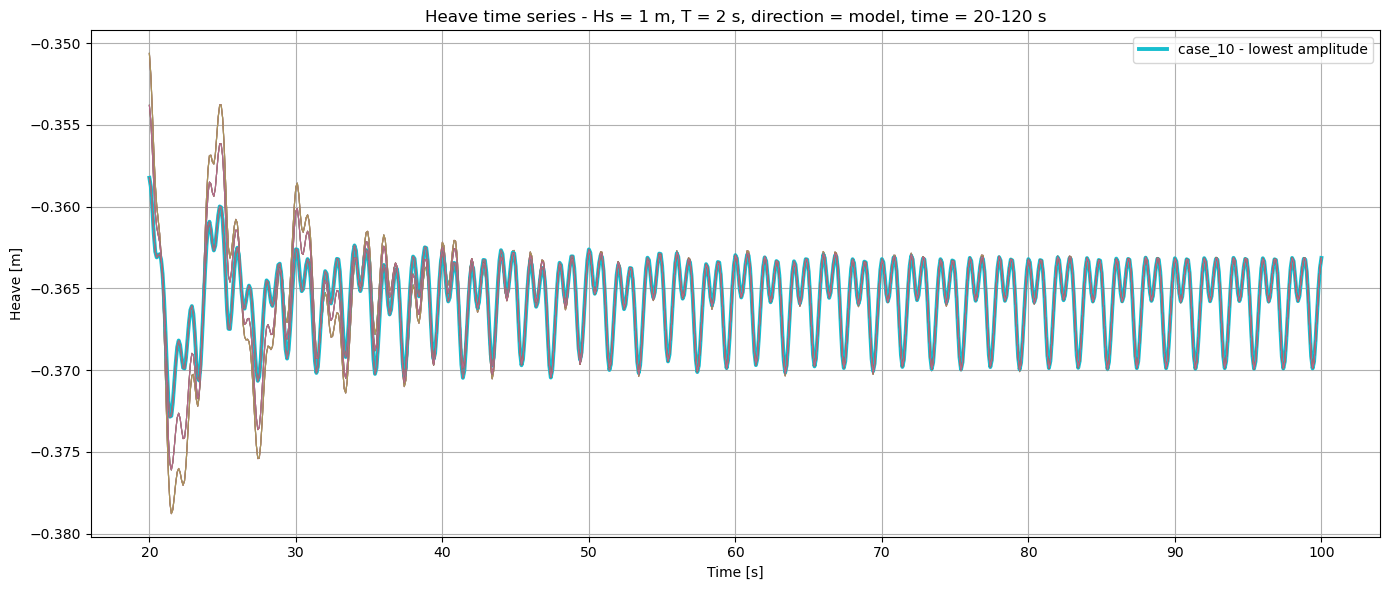

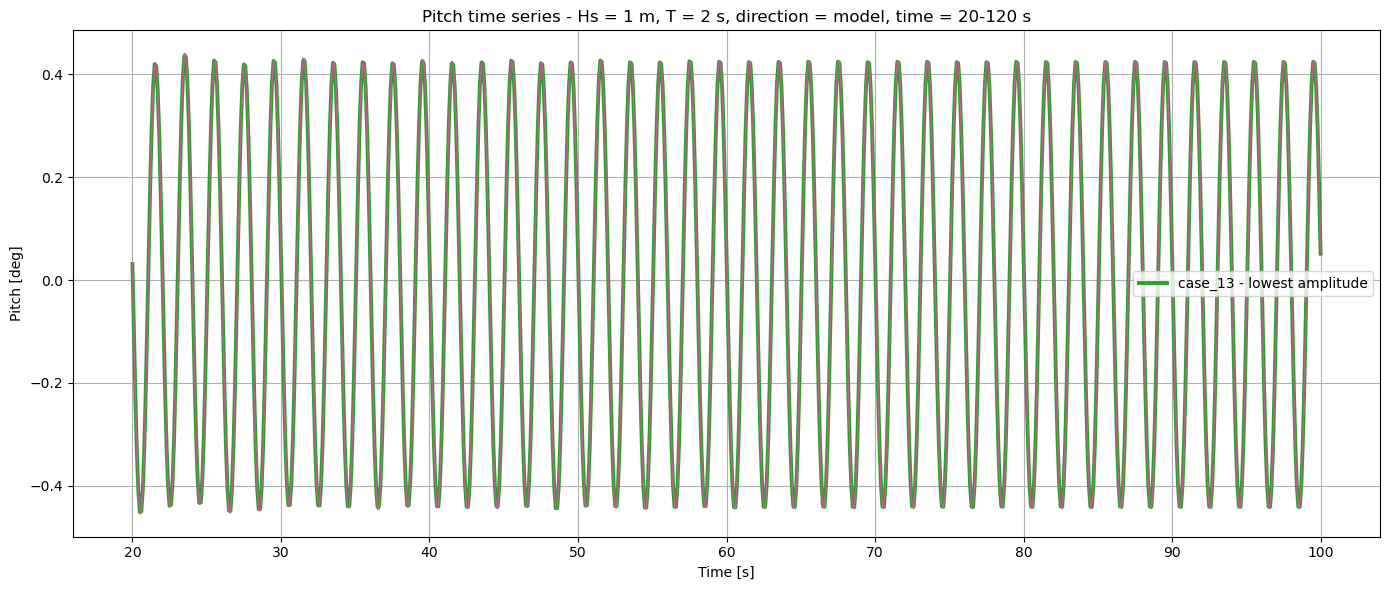

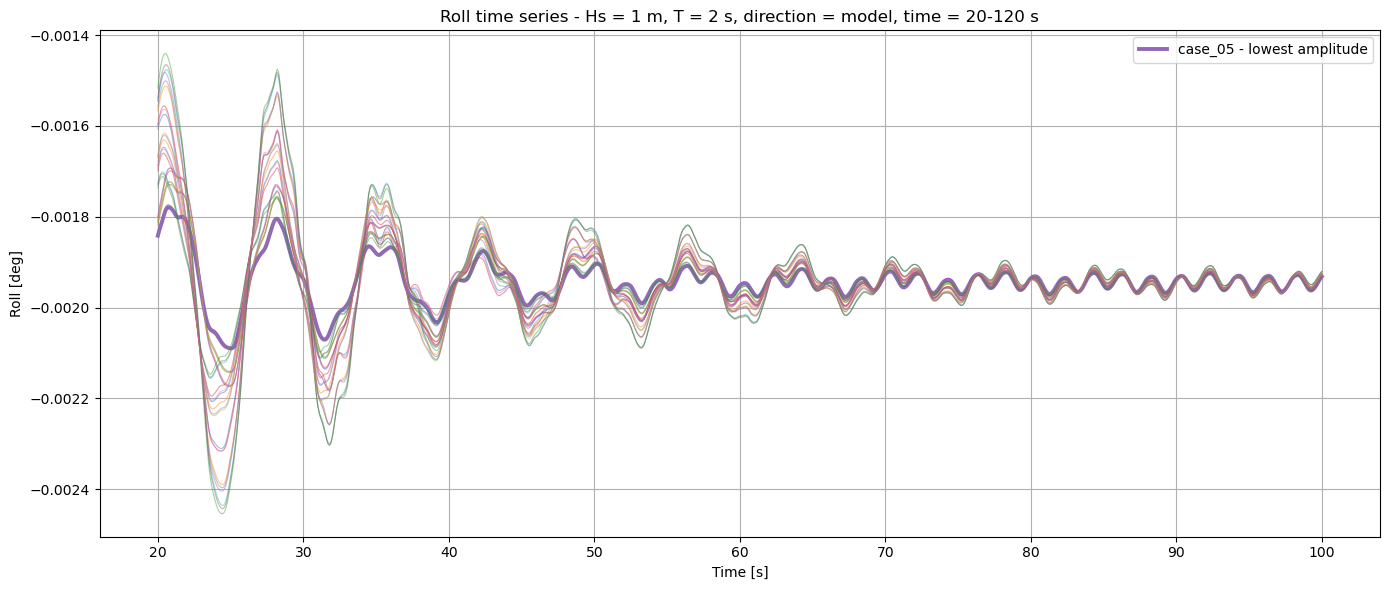

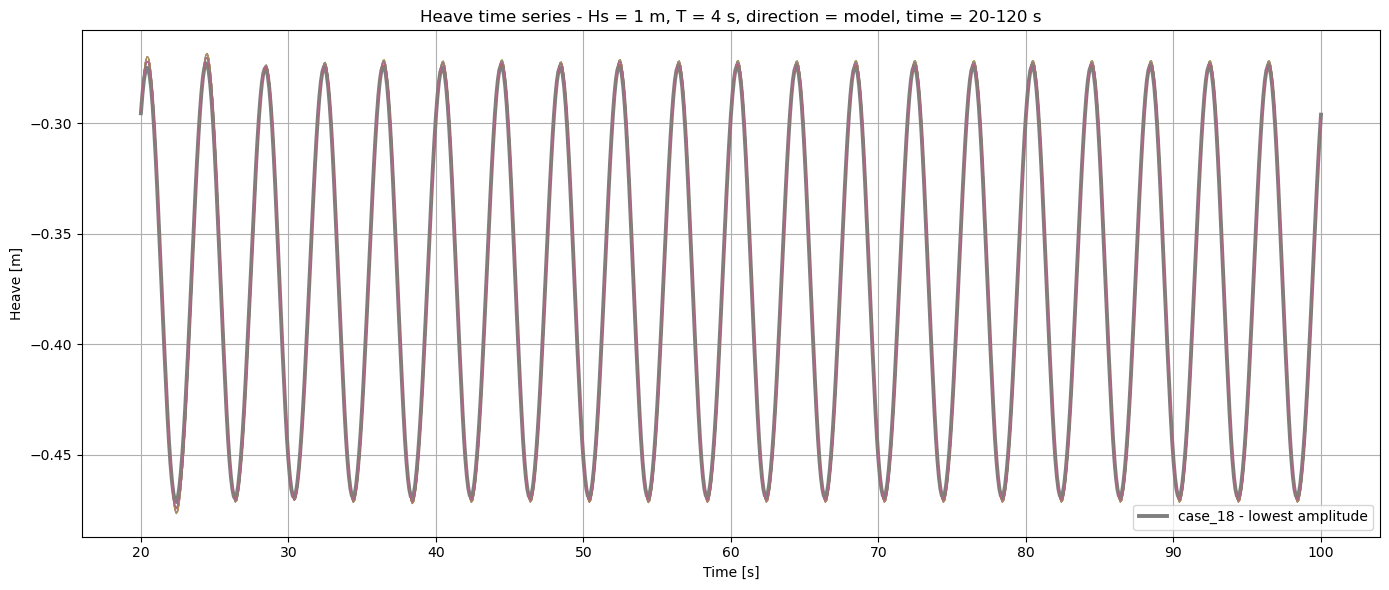

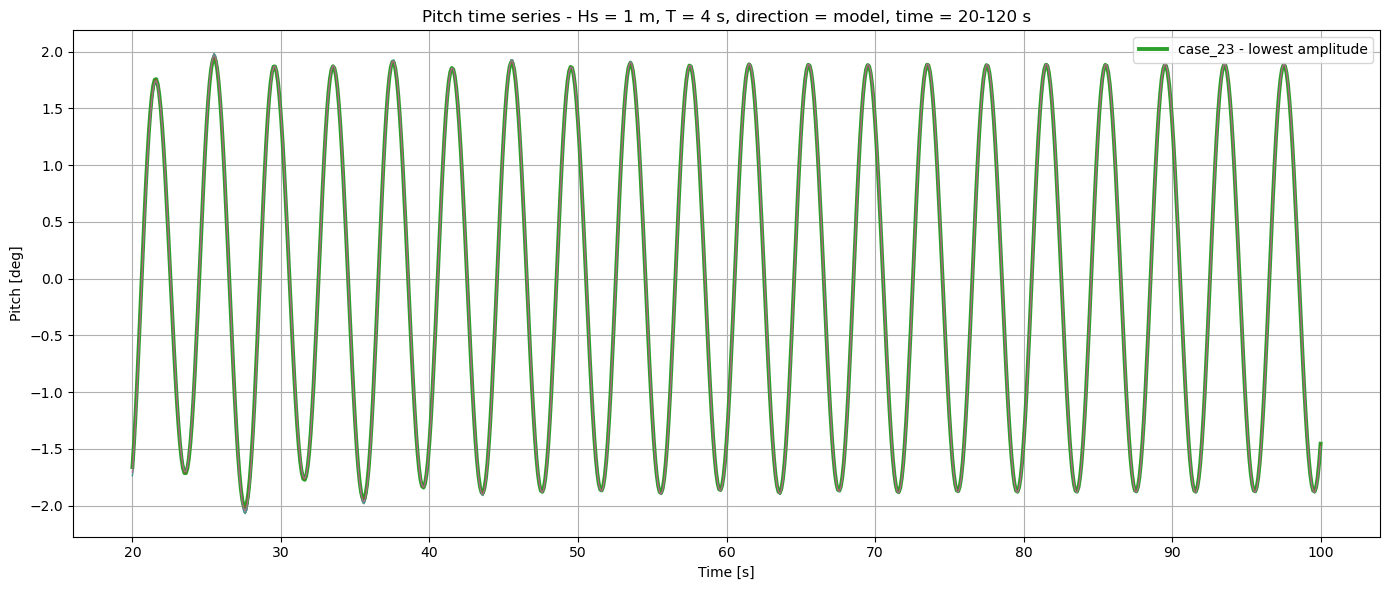

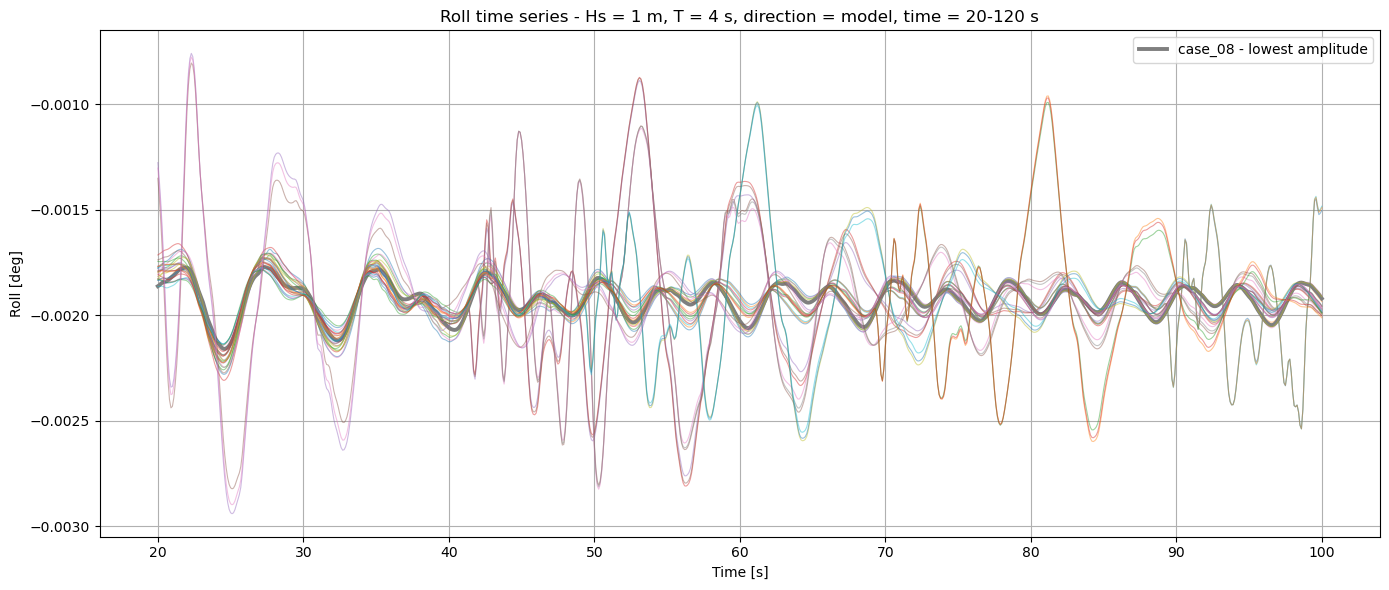

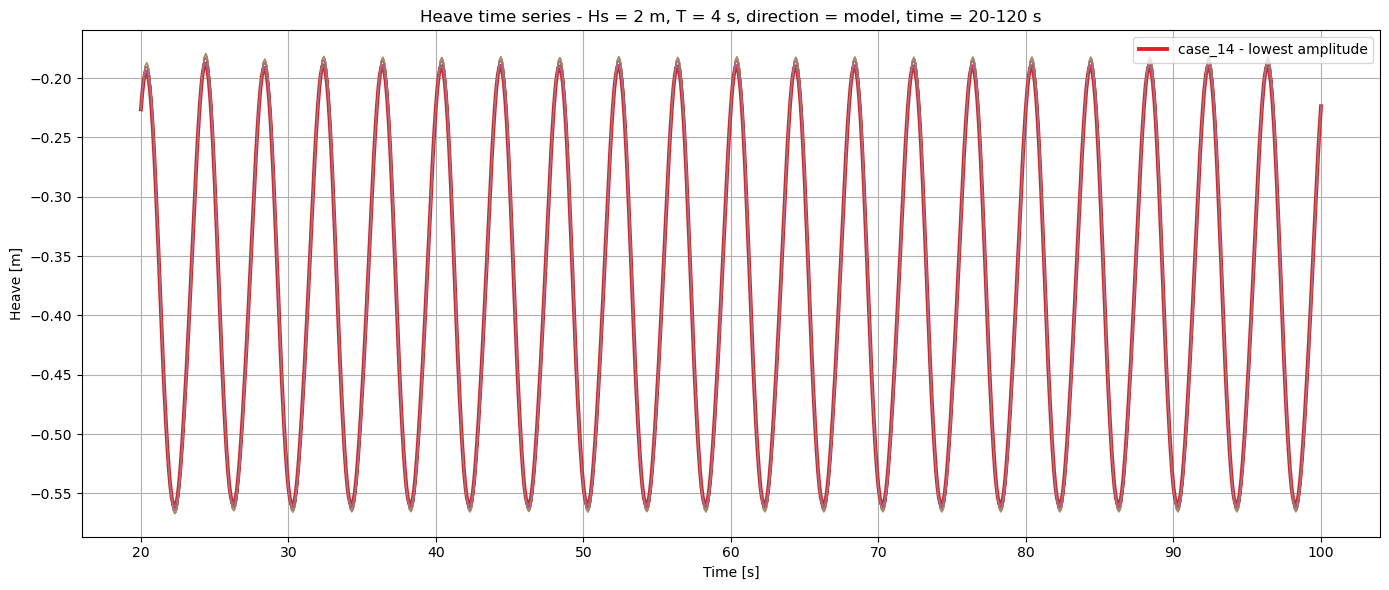

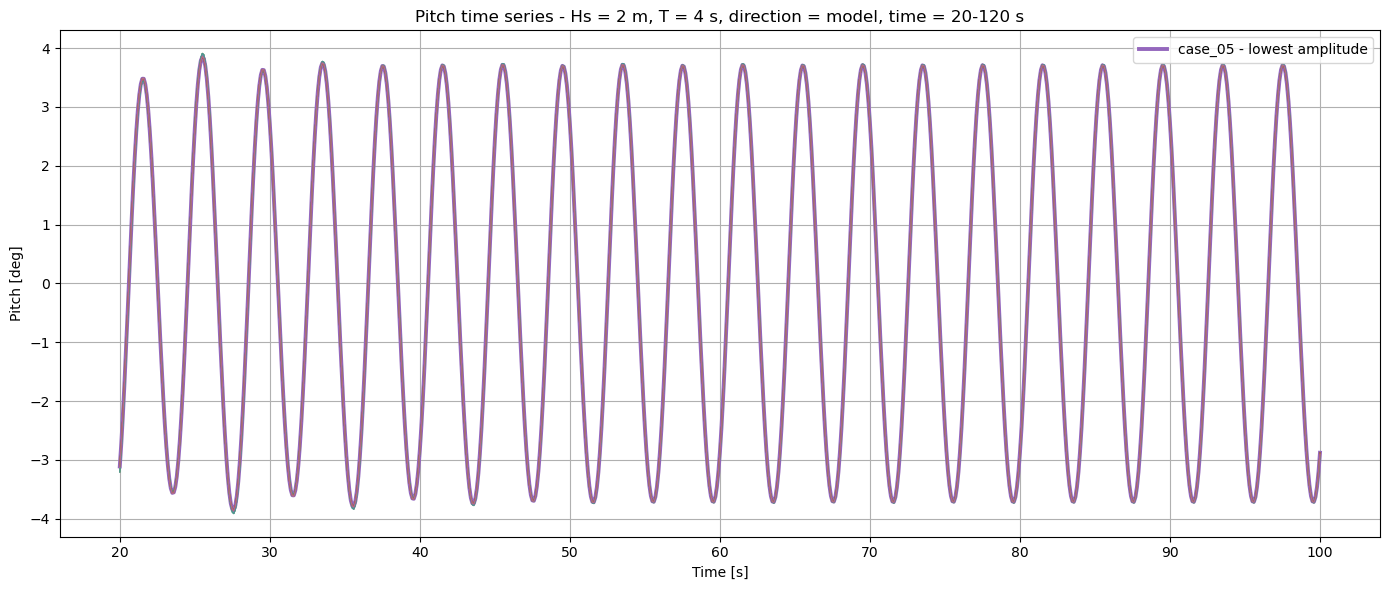

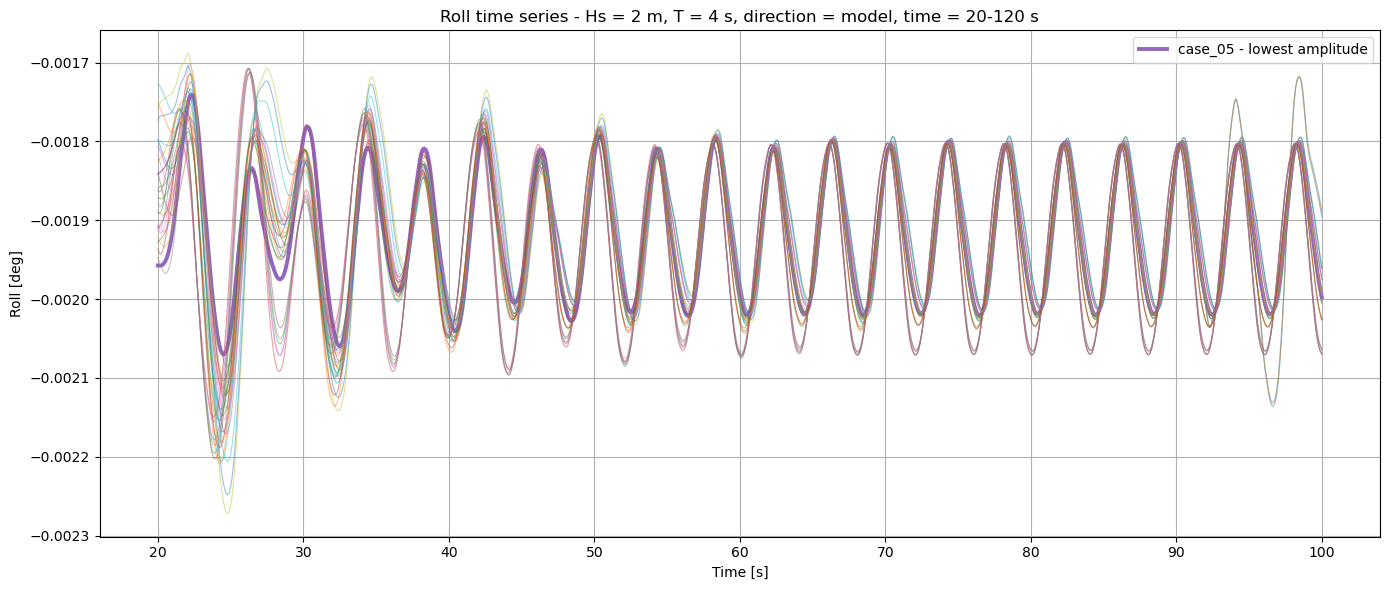

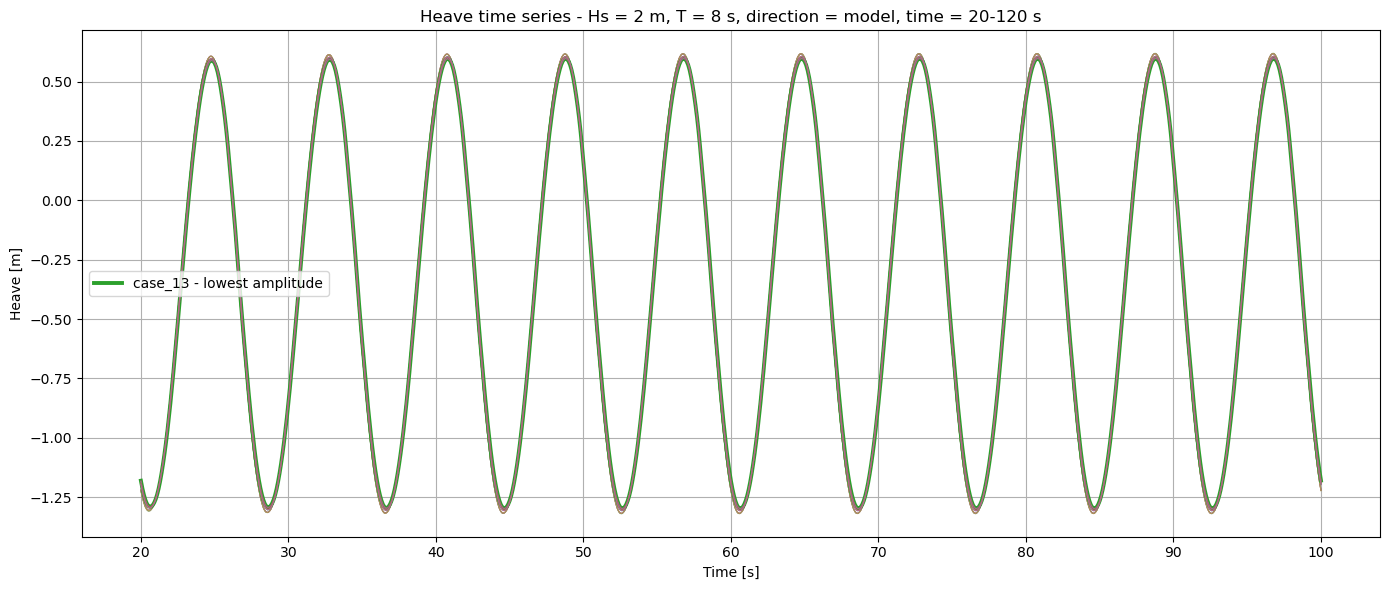

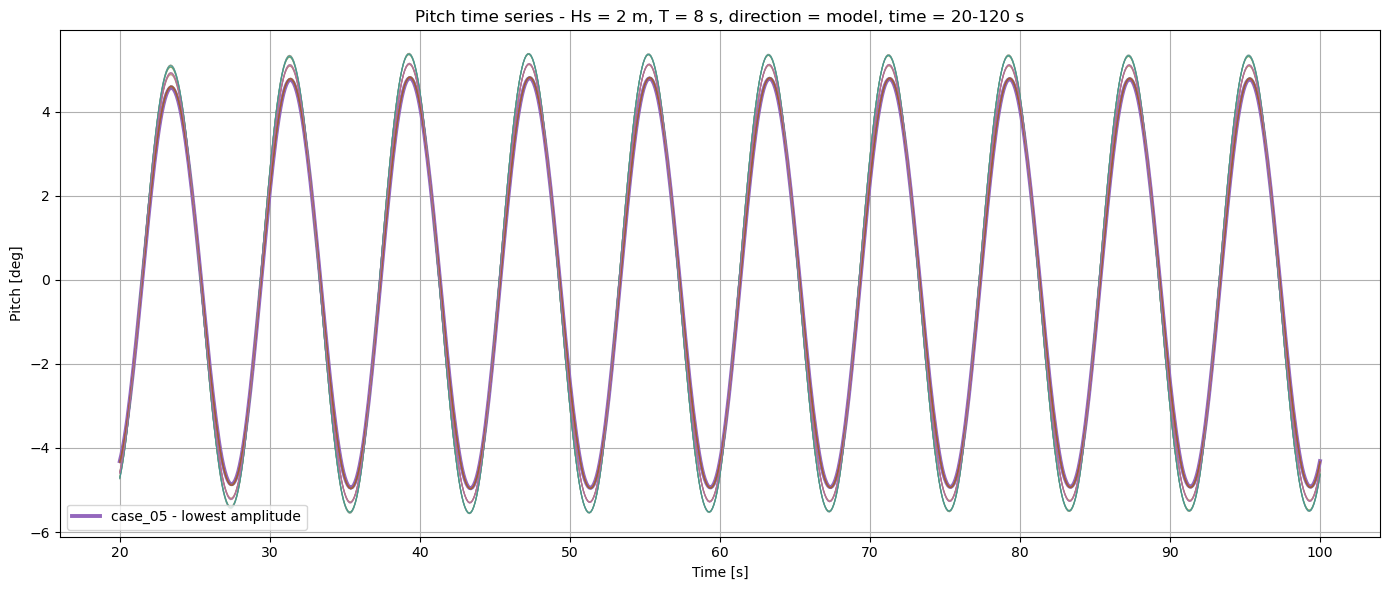

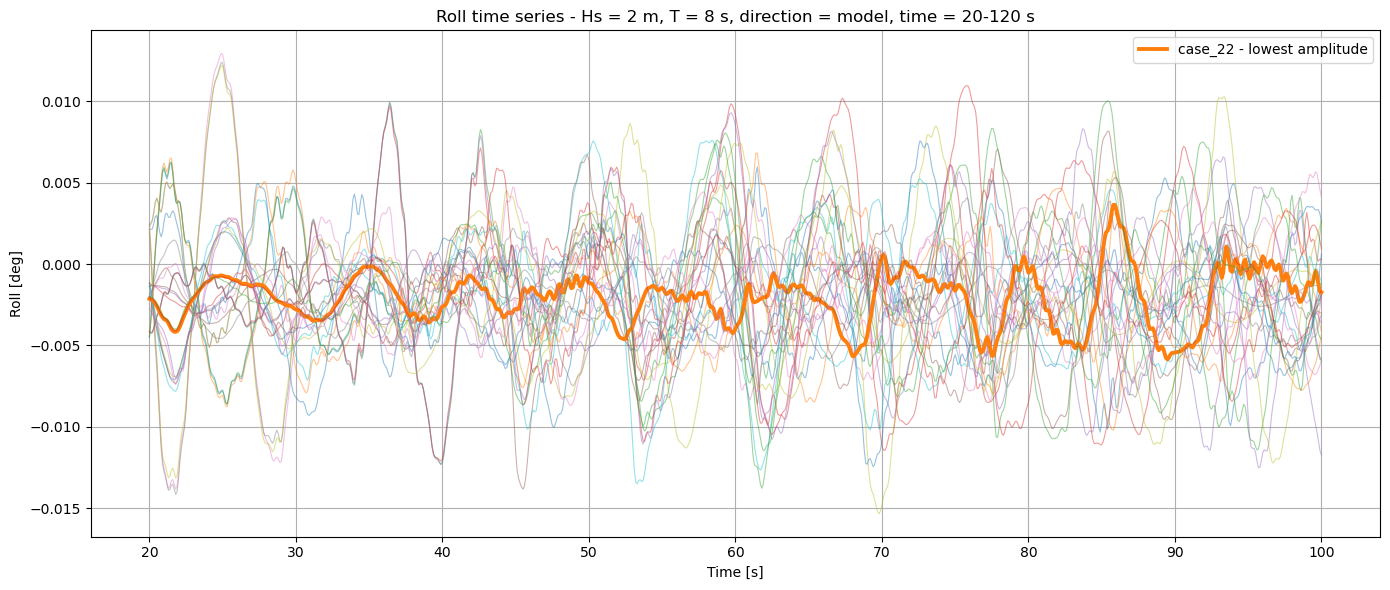

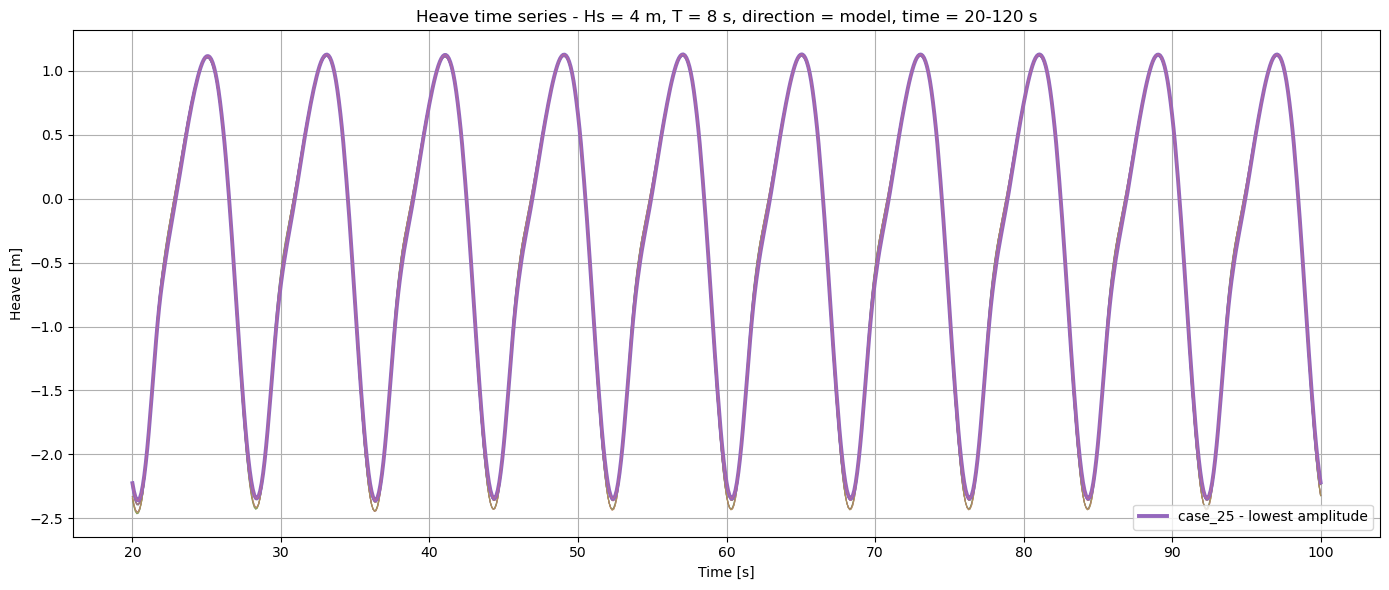

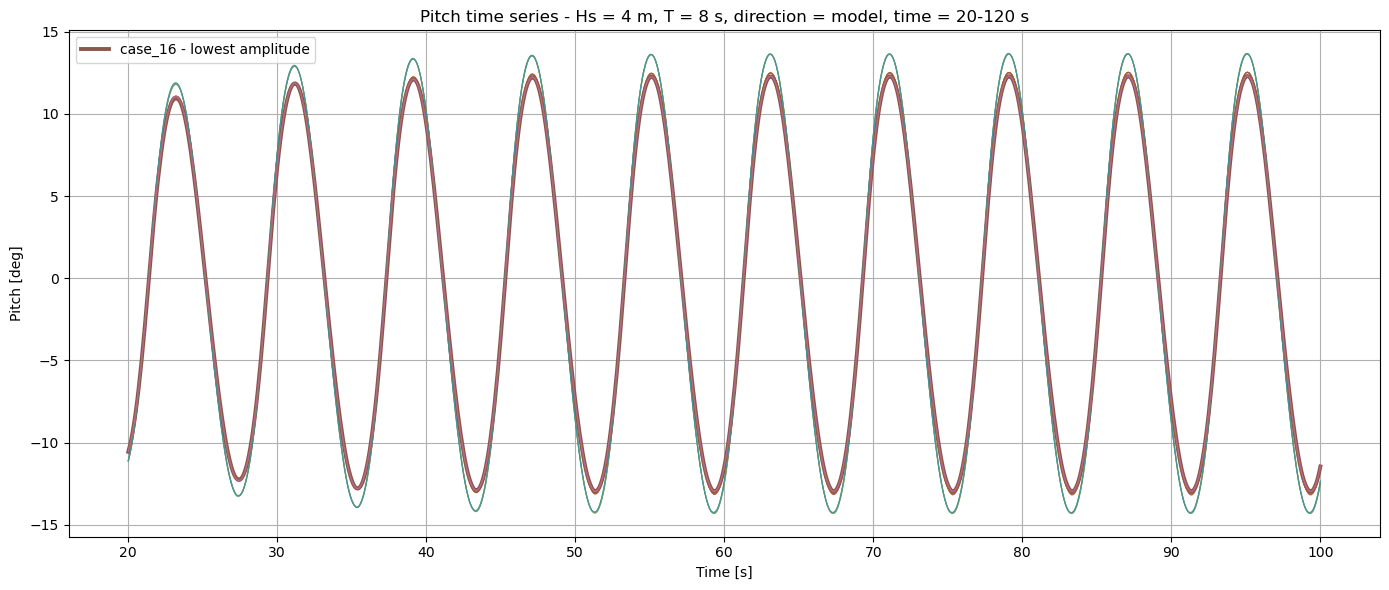

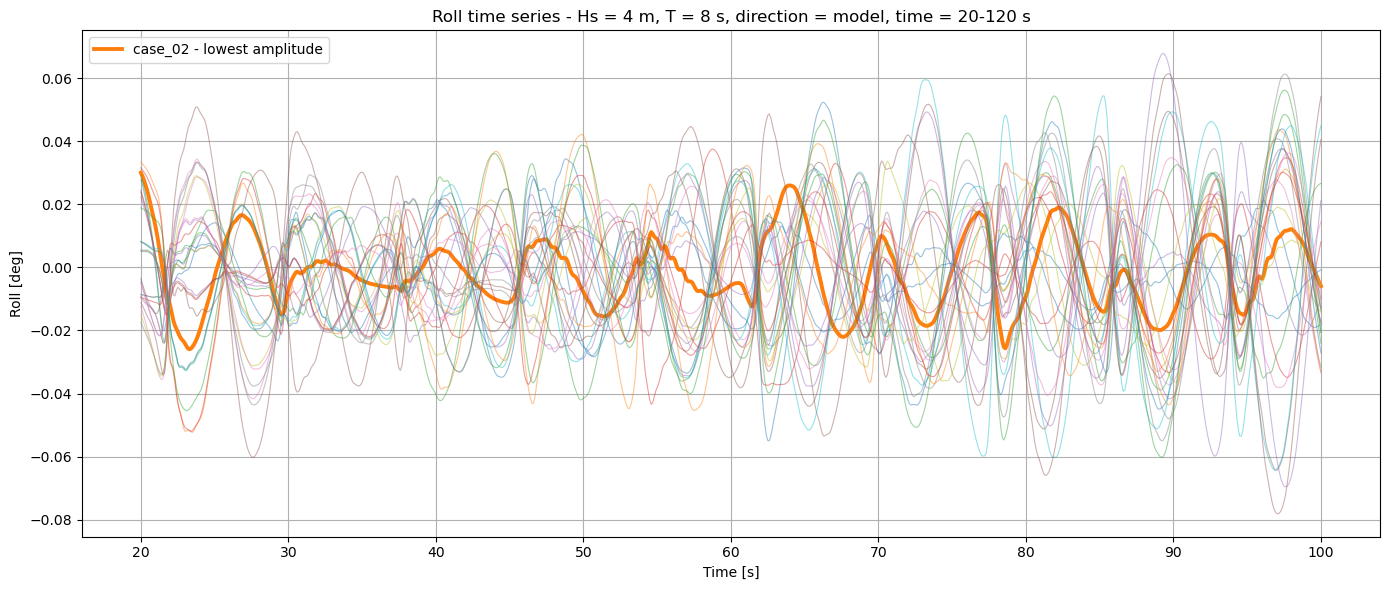

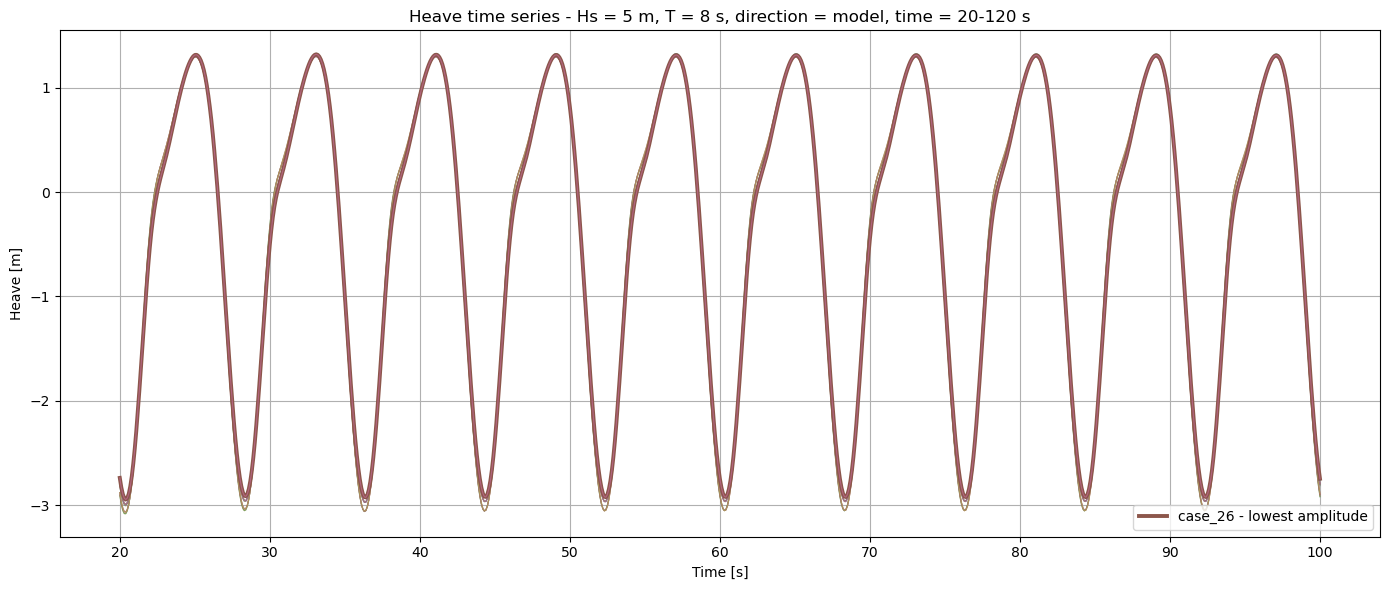

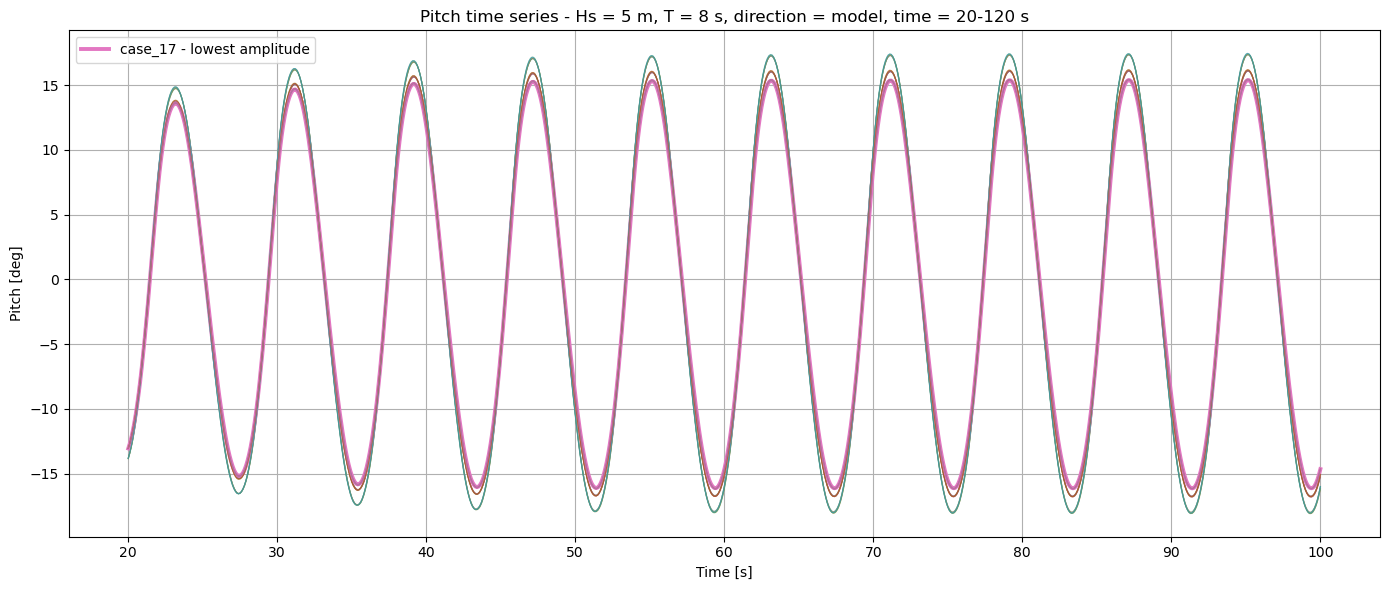

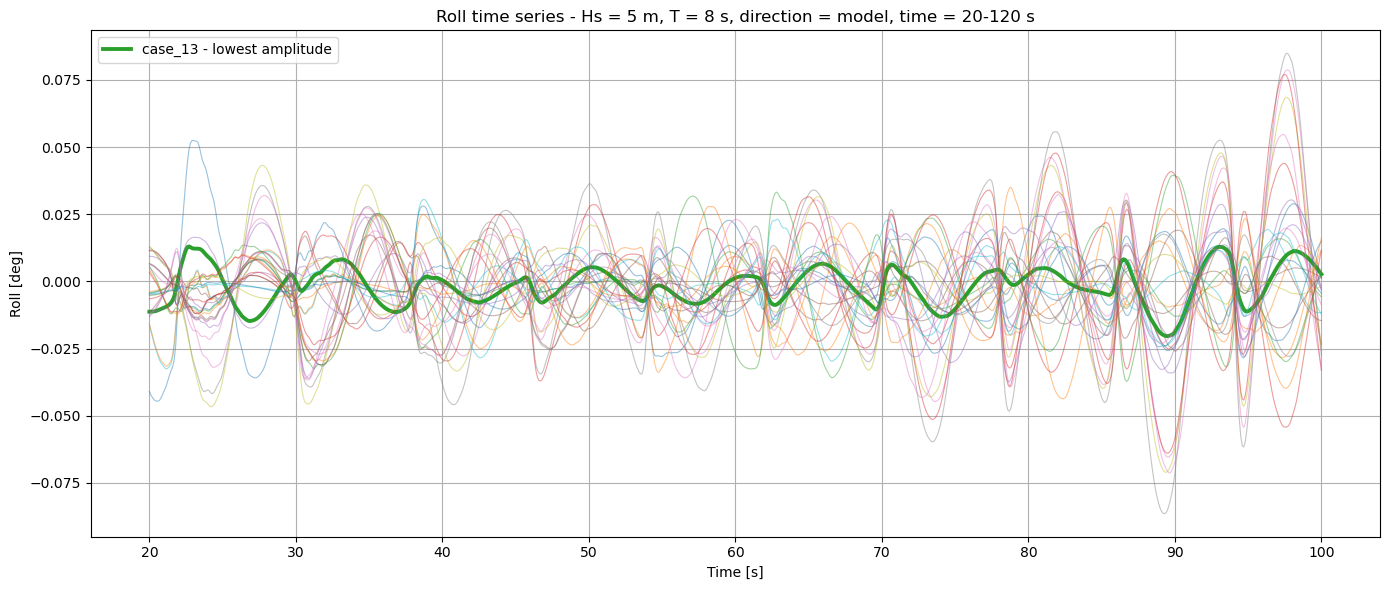

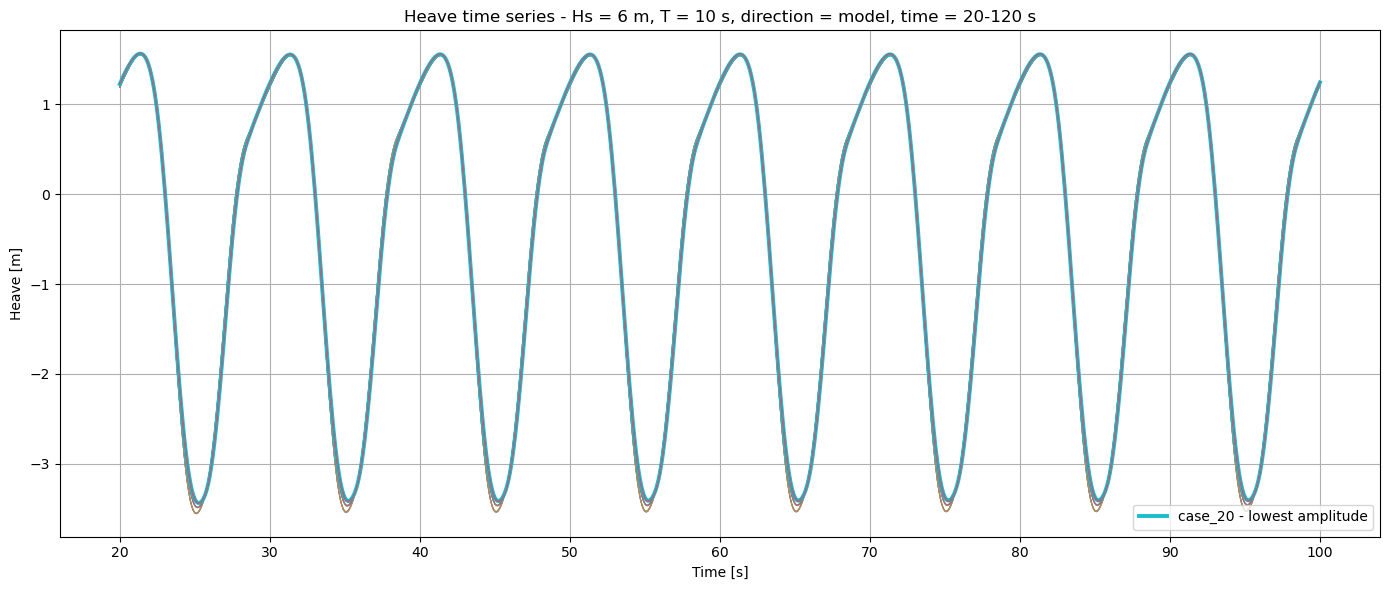

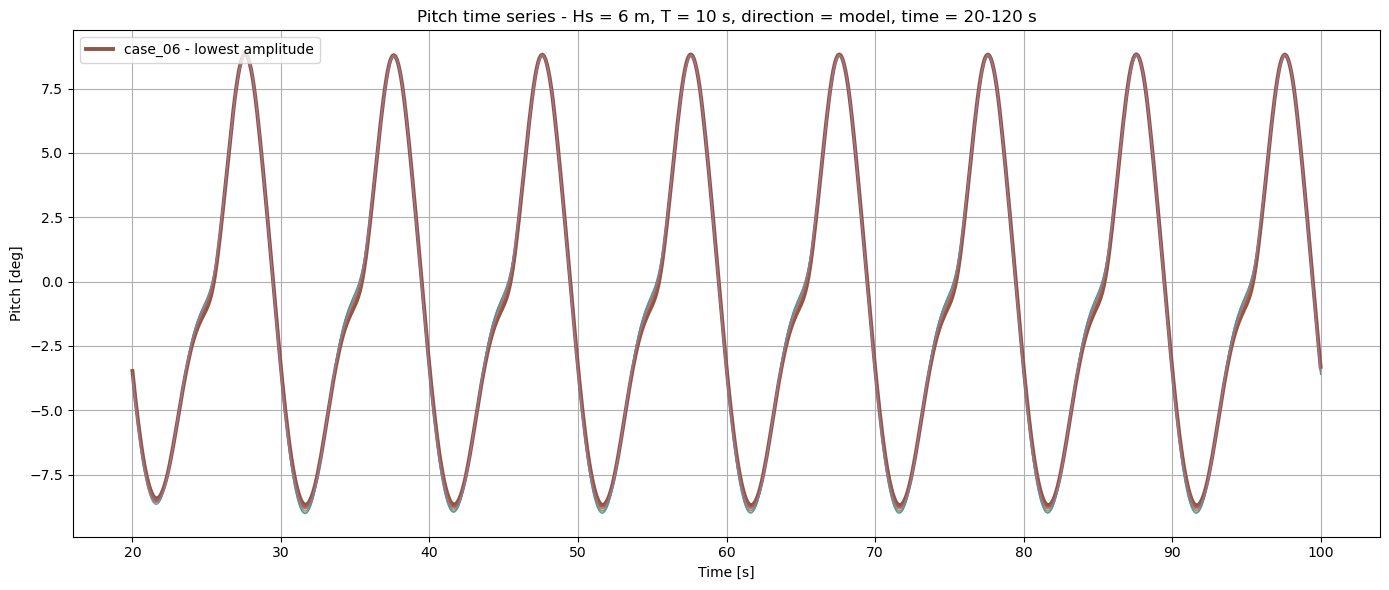

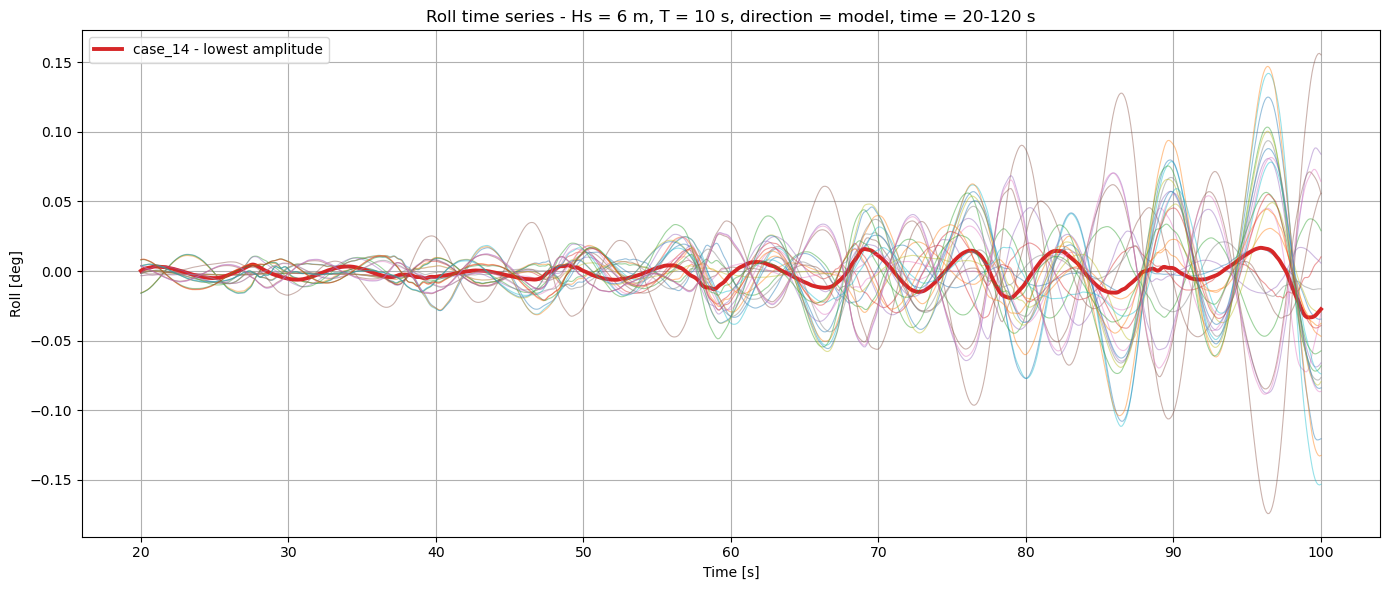

Opgeslagen tijdseriefiguren:
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp2_Dirmodel_heave_timeseries.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp2_Dirmodel_pitch_timeseries.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp2_Dirmodel_roll_timeseries.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp4_Dirmodel_heave_timeseries.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp4_Dirmodel_pitch_timeseries.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp4_Dirmodel_roll_timeseries.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs2_Tp4_Dirmodel_heave_timeseries.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs2_Tp4_Dirmodel_pitch_timeseries.png
C:\Users\verav\Deskto

In [17]:
# ============================================================
# 7. Tijdserieplots: 100-200 s, alle 27 cases met beste case dikker
# ============================================================

response_labels = {
    "heave": ("Heave", "Heave [m]"),
    "pitch": ("Pitch", "Pitch [deg]"),
    "roll":  ("Roll", "Roll [deg]"),
}

saved_figures = []

for sea_state in sea_conditions:
    Hs = float(sea_state["Hs"])
    Tp = float(sea_state["Tp"])
    direction = sea_state.get("direction", None)
    direction_label = "model" if direction is None else f"{float(direction):g}°"
    sea_key = sea_key_from_state(sea_state)

    for response_name, (response_title, ylabel) in response_labels.items():
        fig, ax = plt.subplots(figsize=(14, 6))

        best_case_name = None
        if highlight_best_case and len(best_cases) > 0:
            row = best_cases[(best_cases["sea_key"].eq(sea_key)) & (best_cases["response"].eq(response_name))]
            if len(row) > 0:
                best_case_name = row.iloc[0]["case"]

        for case_name in DAMPING_CASES.keys():
            key = (sea_key, case_name)
            if key not in all_time_histories:
                continue

            data = all_time_histories[key]
            t = data["t"]
            y = data[response_name]
            mask = plot_mask(t)

            if case_name == best_case_name:
                ax.plot(t[mask], y[mask], linewidth=2.8, label=f"{case_name} - lowest amplitude")
            else:
                ax.plot(t[mask], y[mask], linewidth=0.8, alpha=0.45)

        ax.set_xlabel("Time [s]")
        ax.set_ylabel(ylabel)
        ax.set_title(
            f"{response_title} time series - Hs = {Hs:g} m, T = {Tp:g} s, "
            f"direction = {direction_label}, time = {plot_start_time:g}-{plot_end_time:g} s"
        )
        ax.grid(True)
        if best_case_name is not None:
            ax.legend()
        fig.tight_layout()

        if save_plots:
            filename = output_dir / f"{safe_name(sea_key)}_{response_name}_timeseries.png"
            fig.savefig(filename, dpi=300, bbox_inches="tight")
            saved_figures.append(filename)

        if show_plots:
            plt.show()
        else:
            plt.close(fig)

print("Opgeslagen tijdseriefiguren:")
for f in saved_figures:
    print(f)

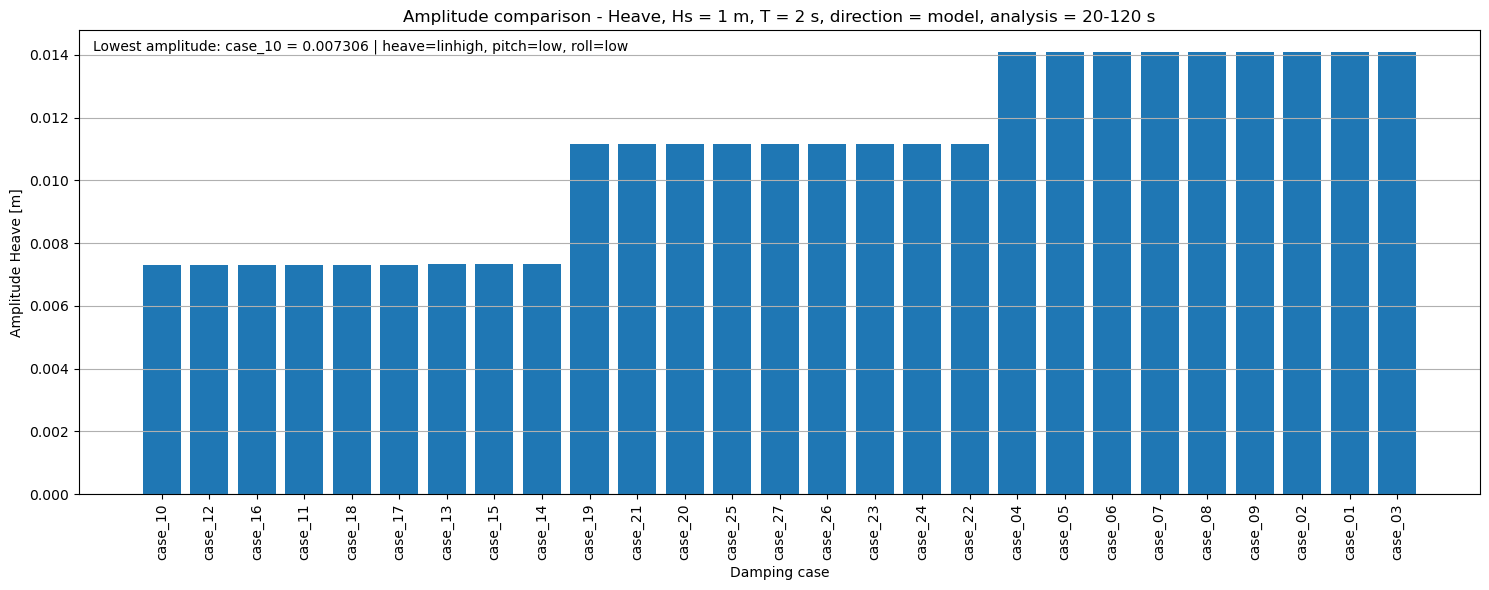

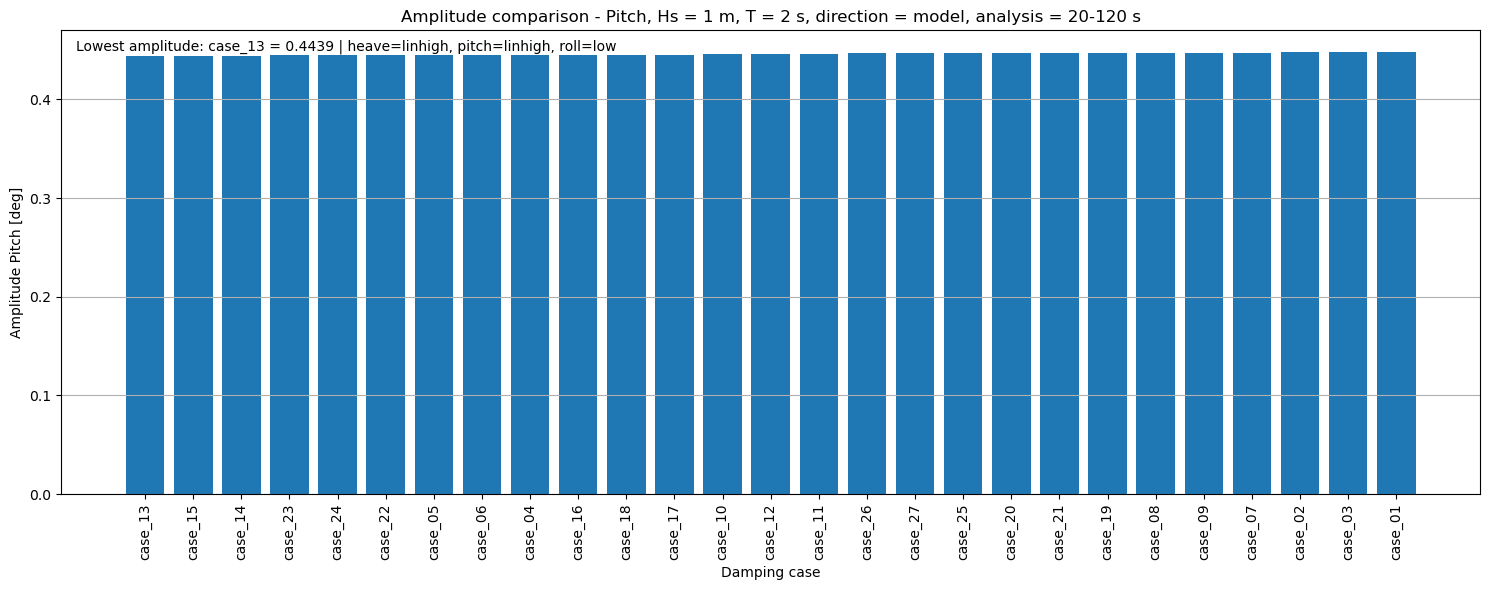

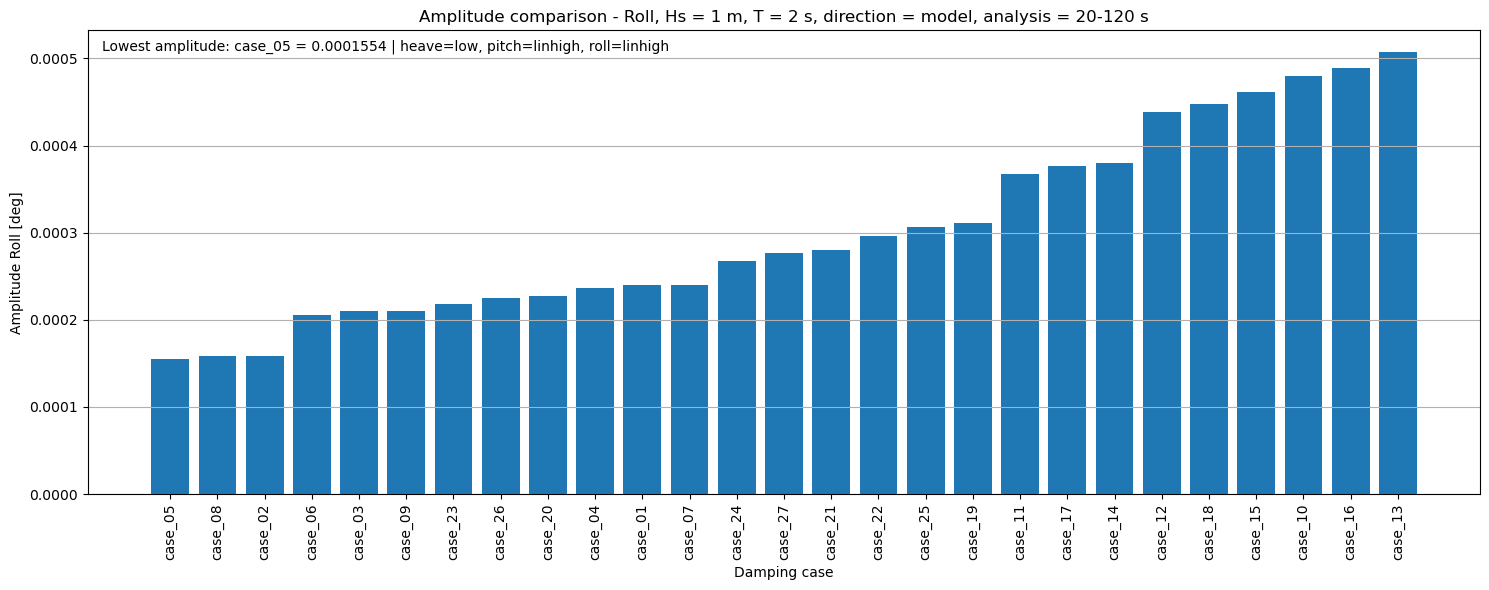

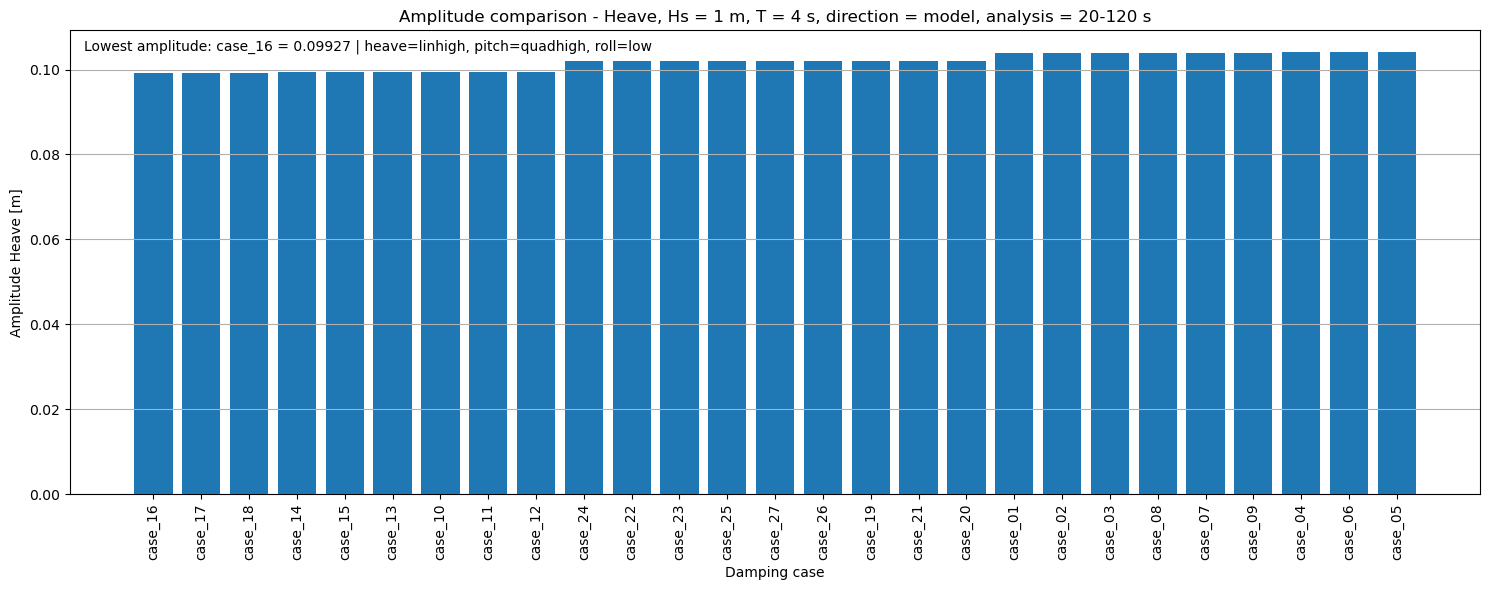

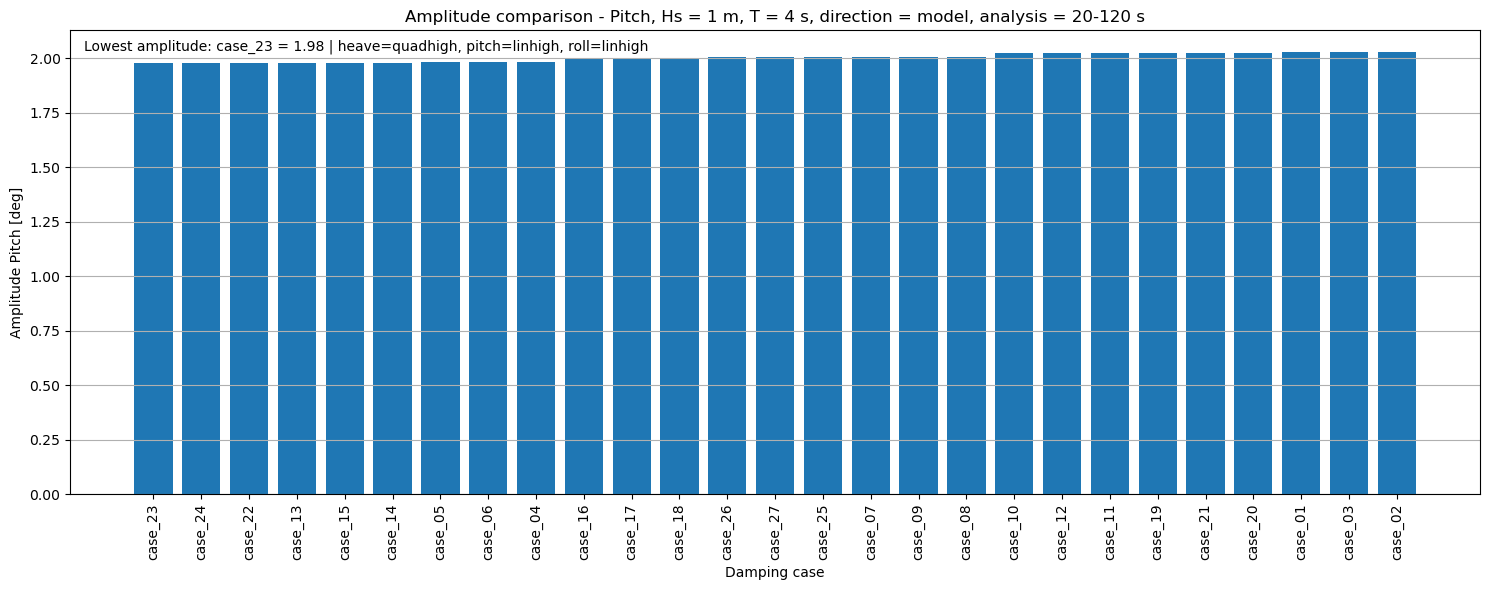

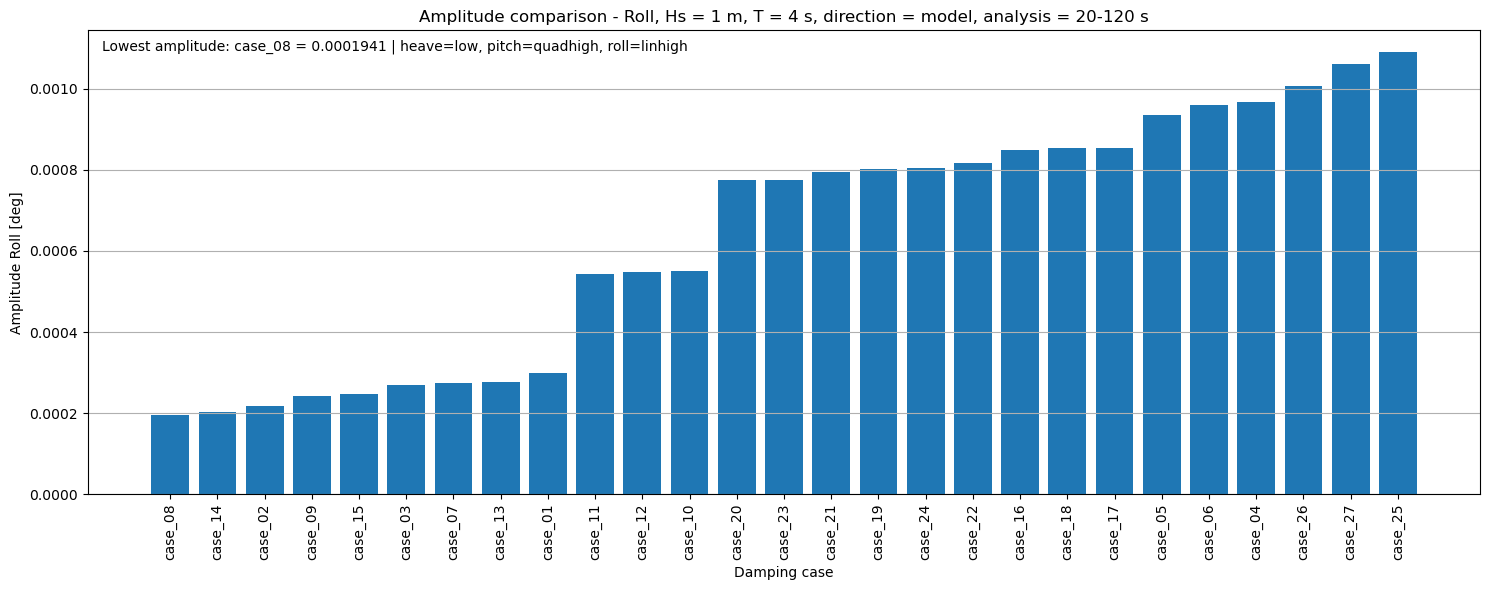

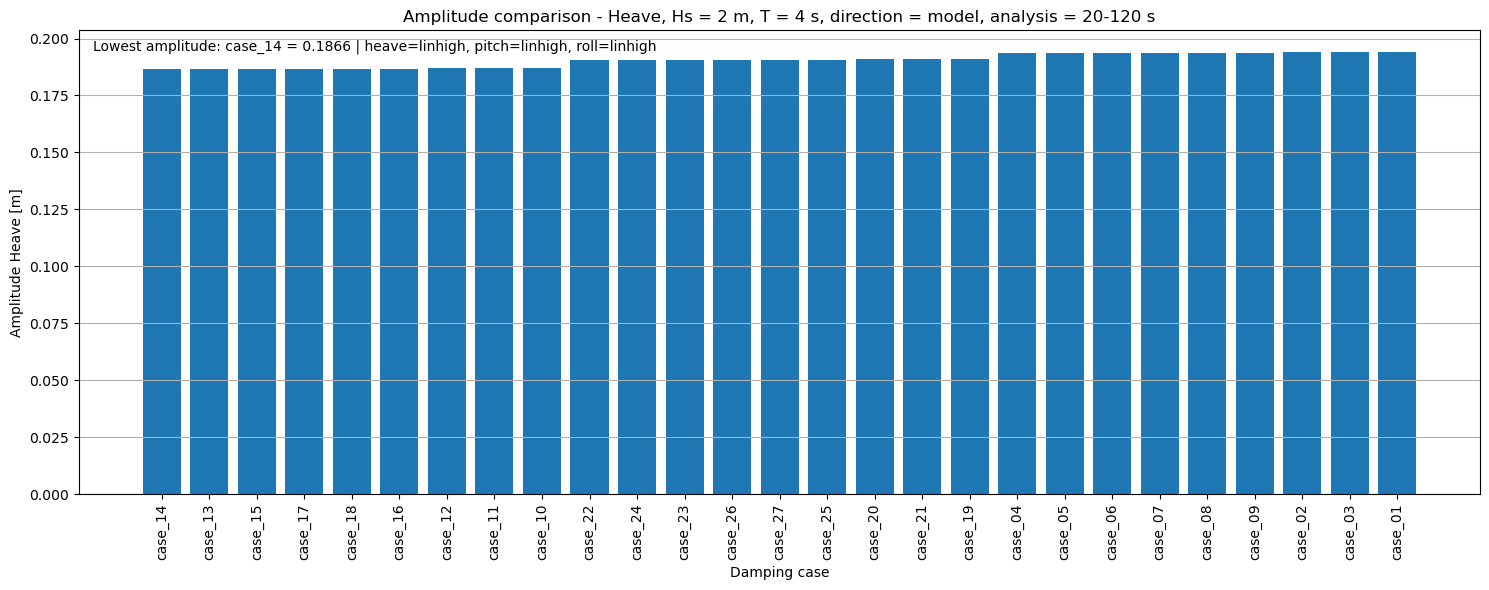

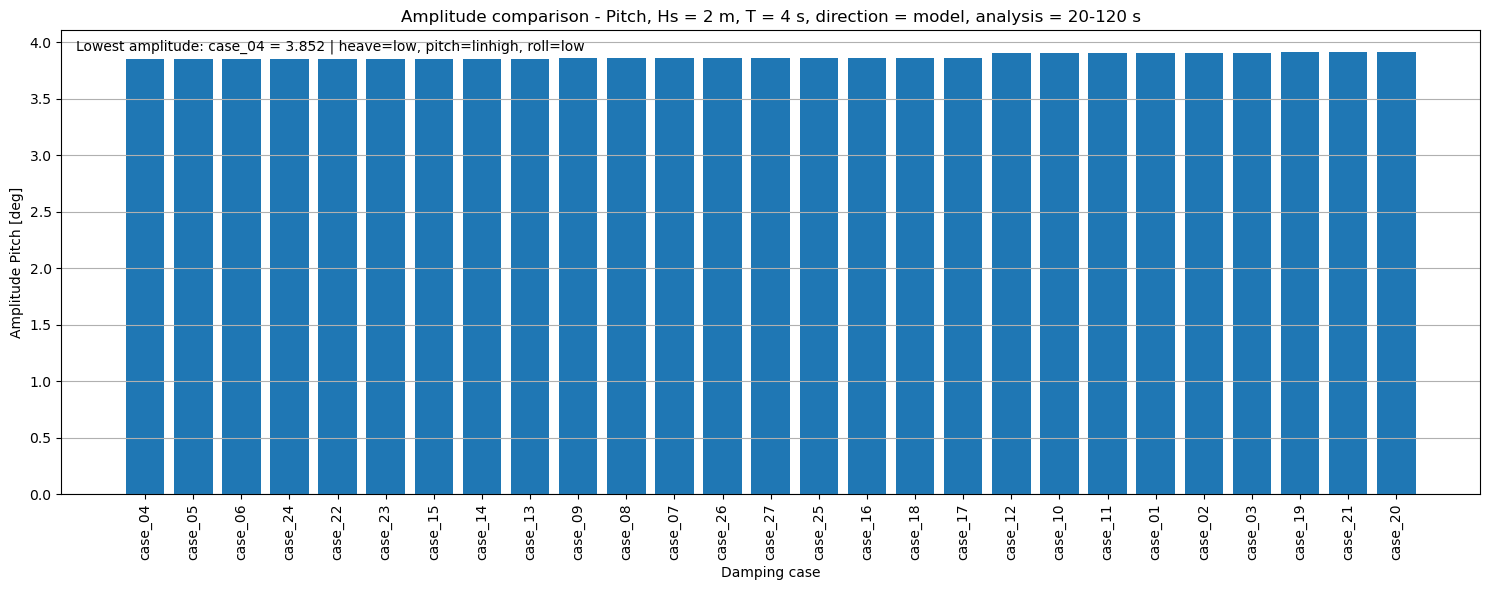

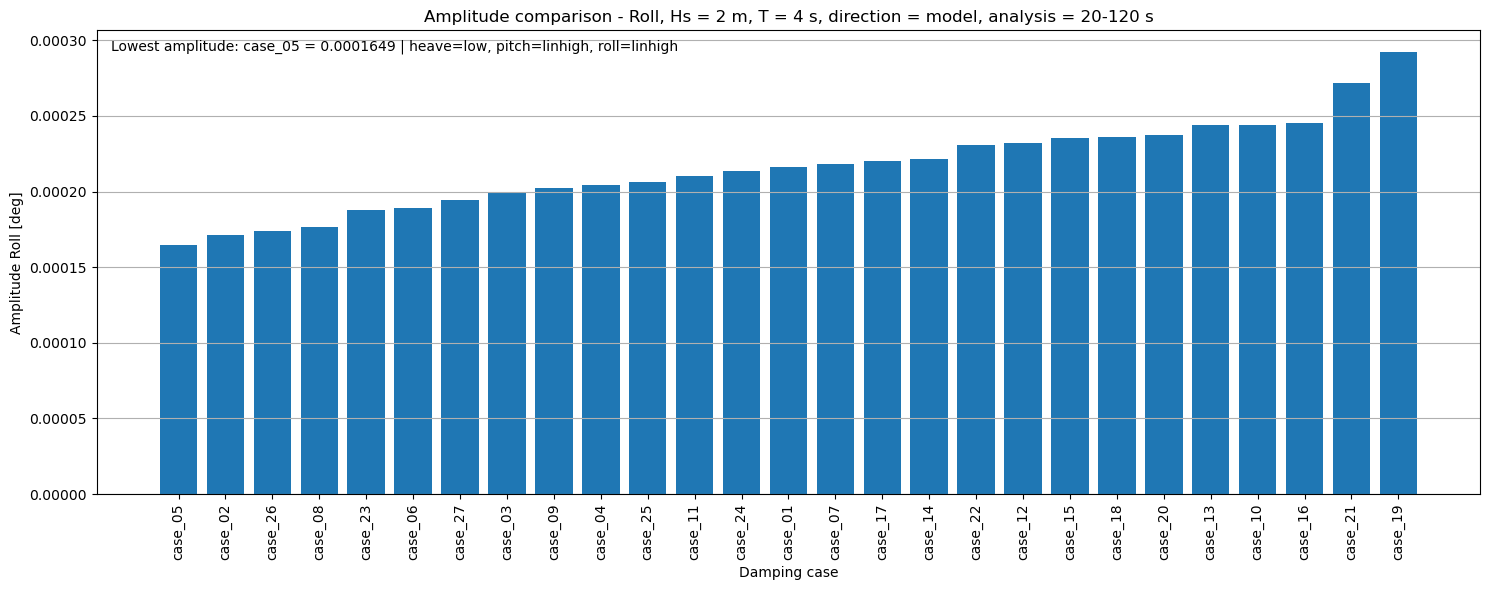

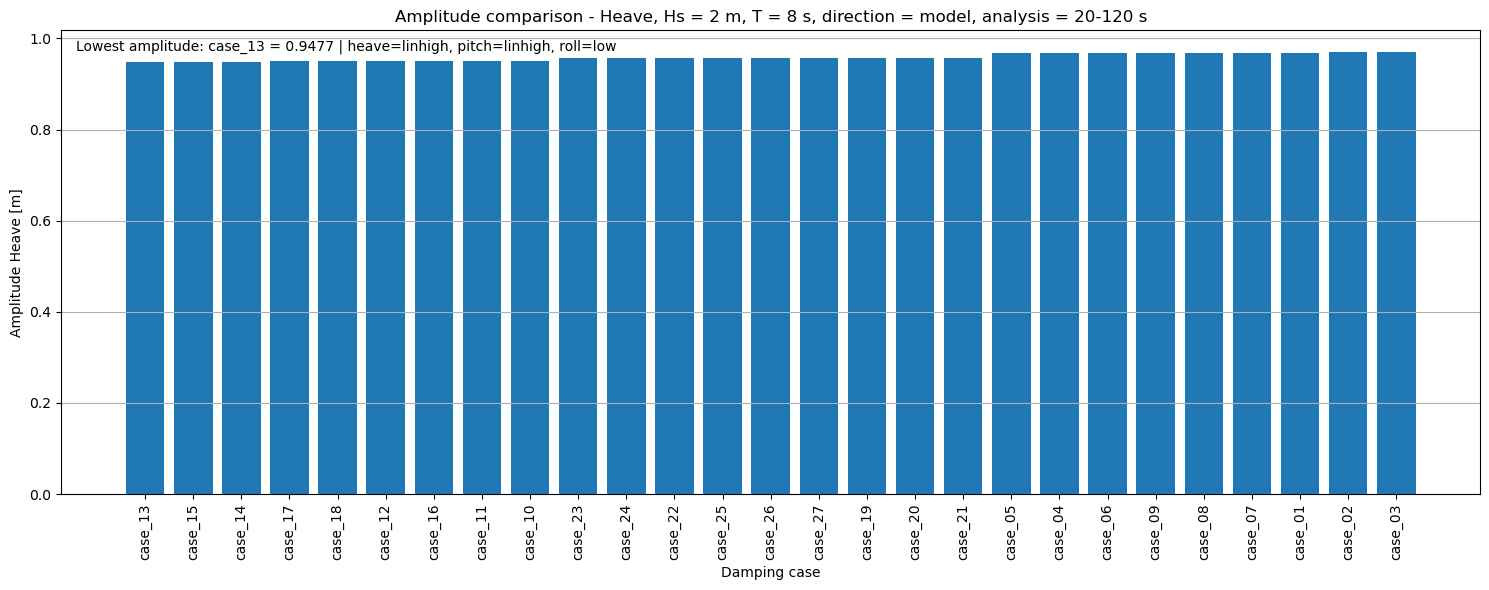

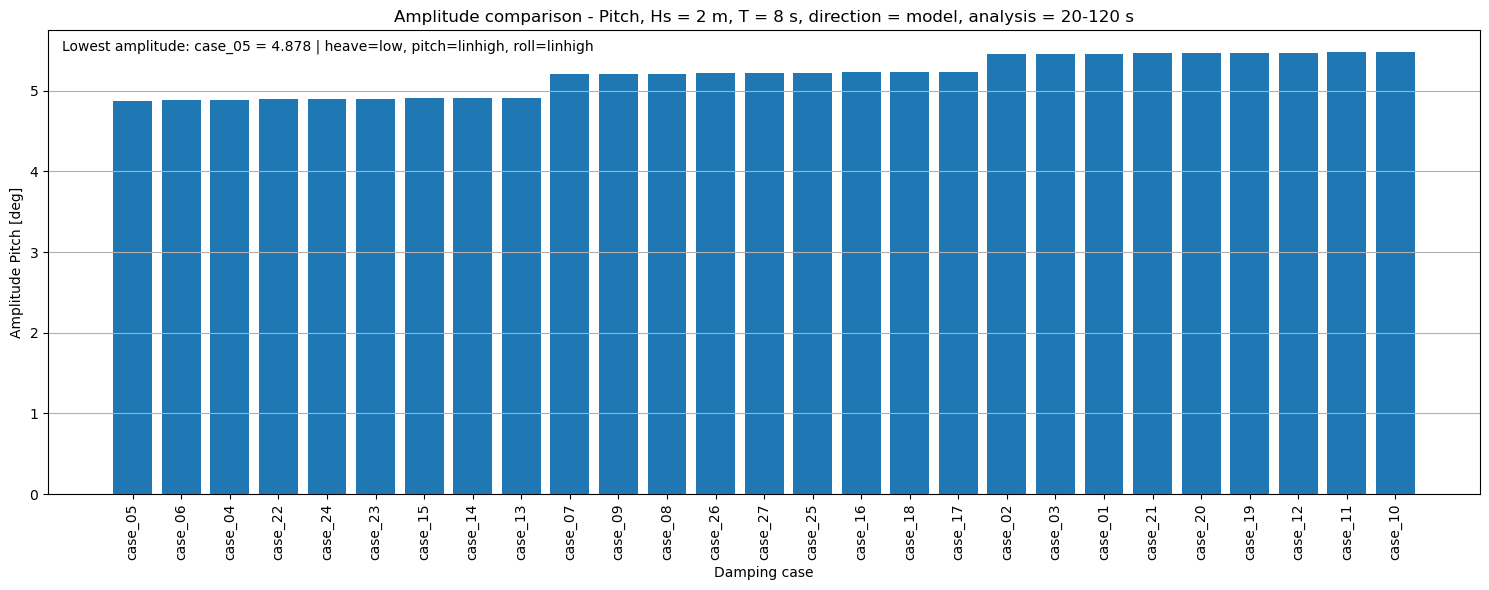

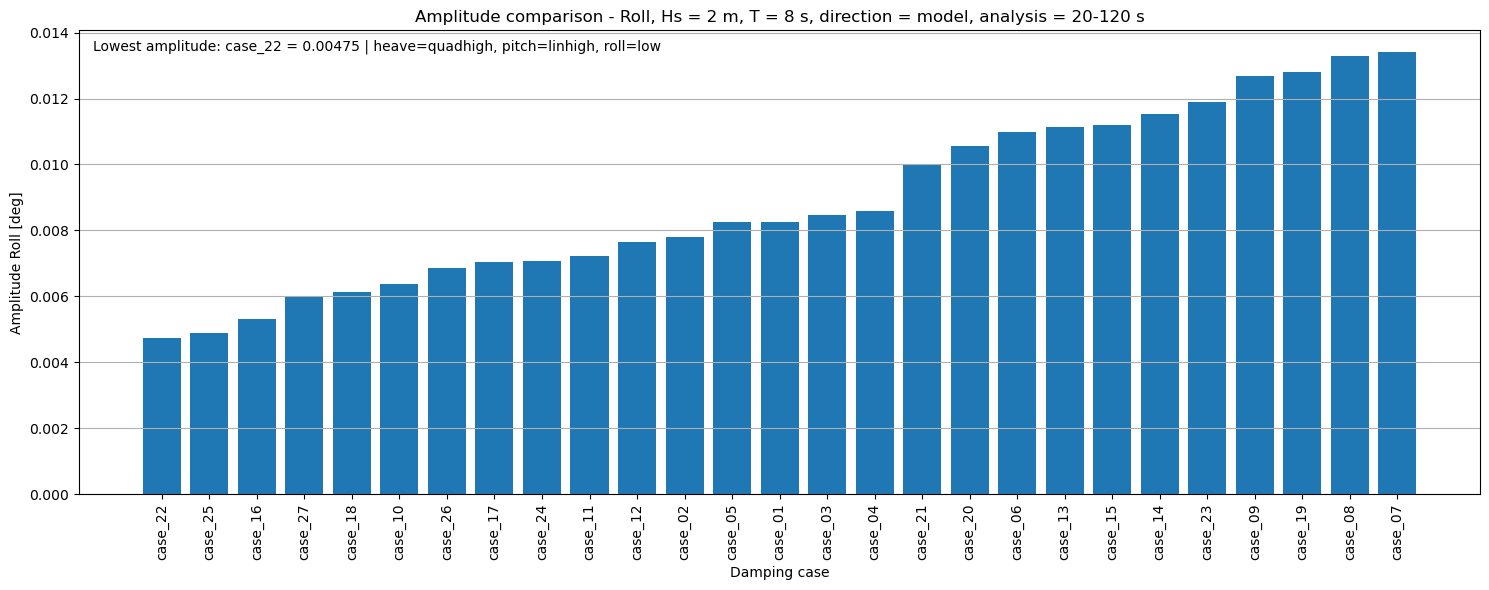

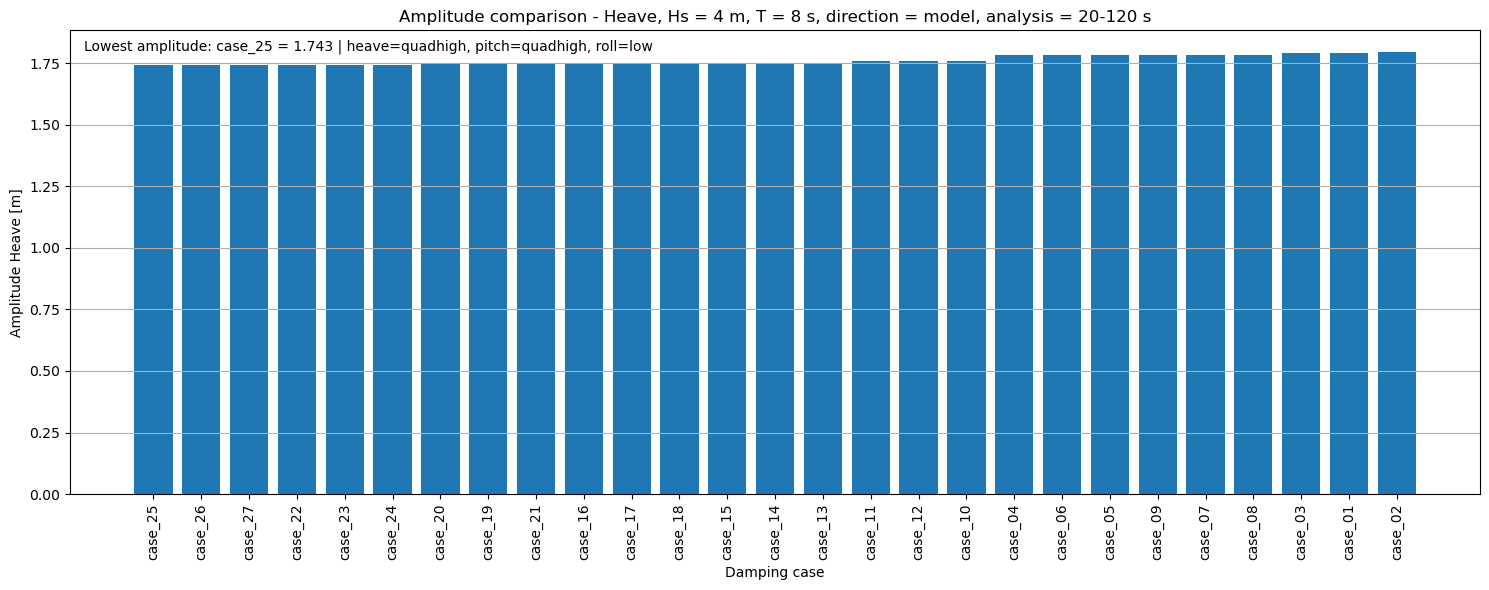

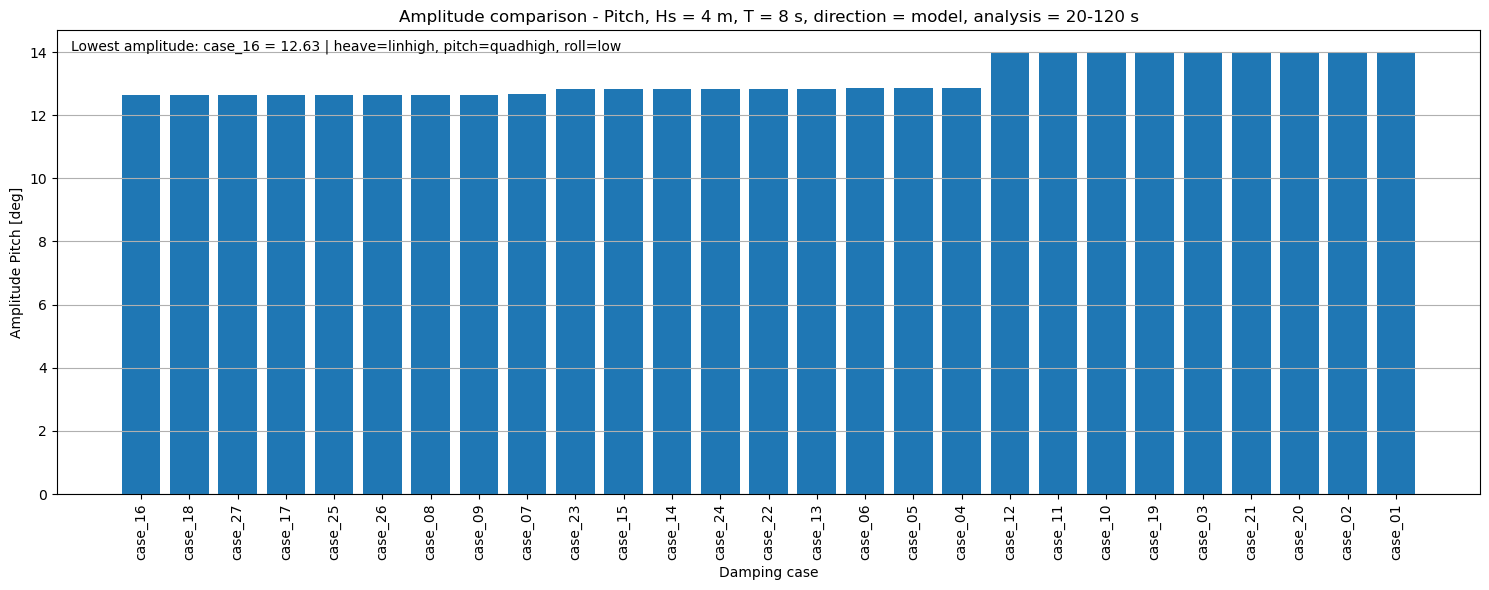

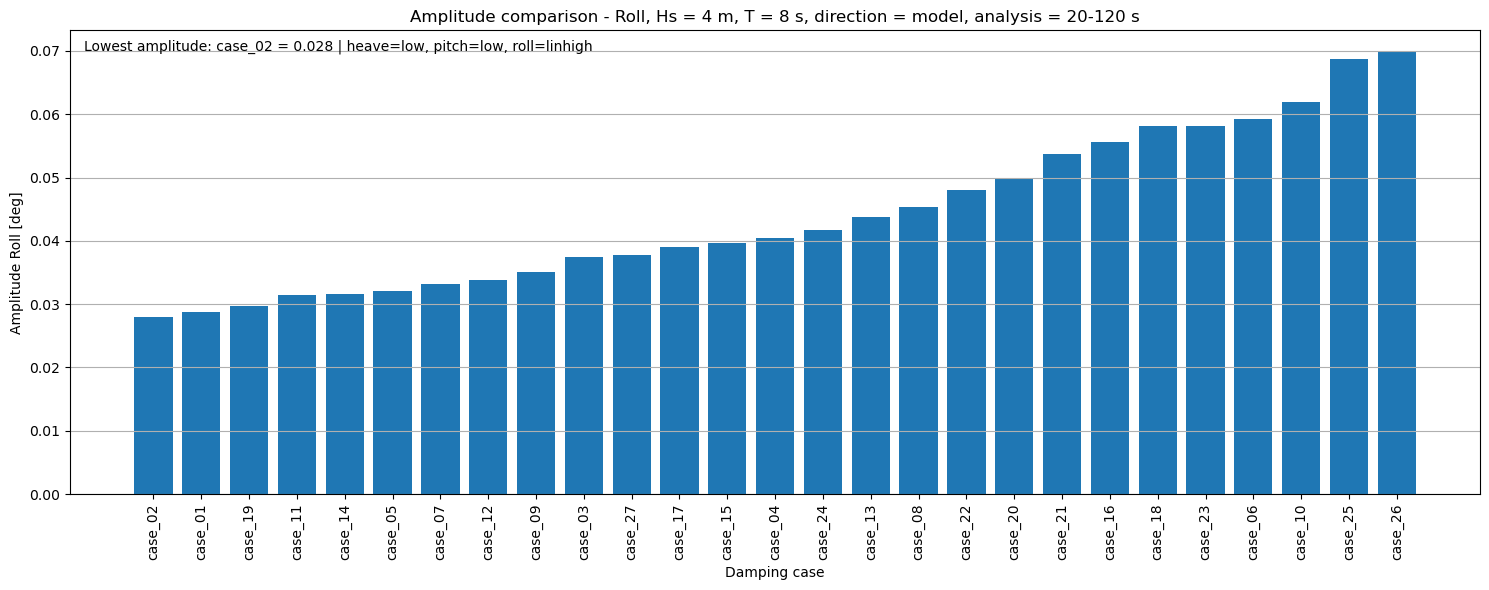

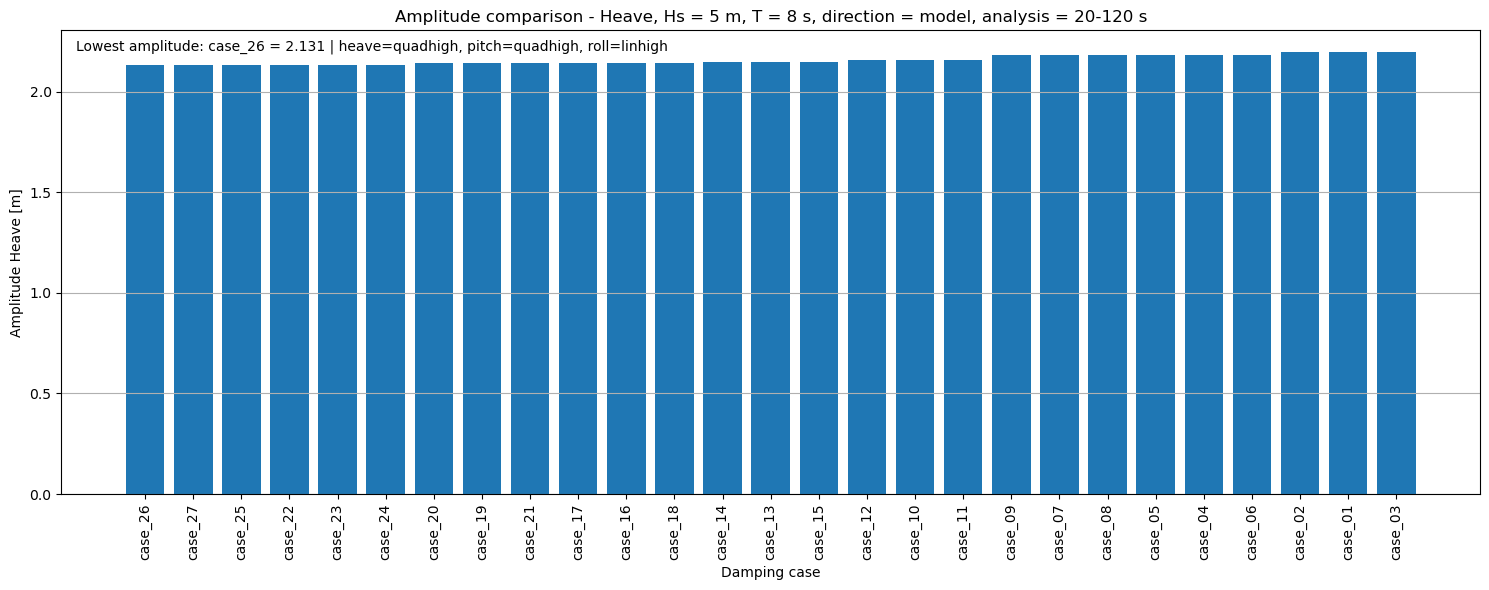

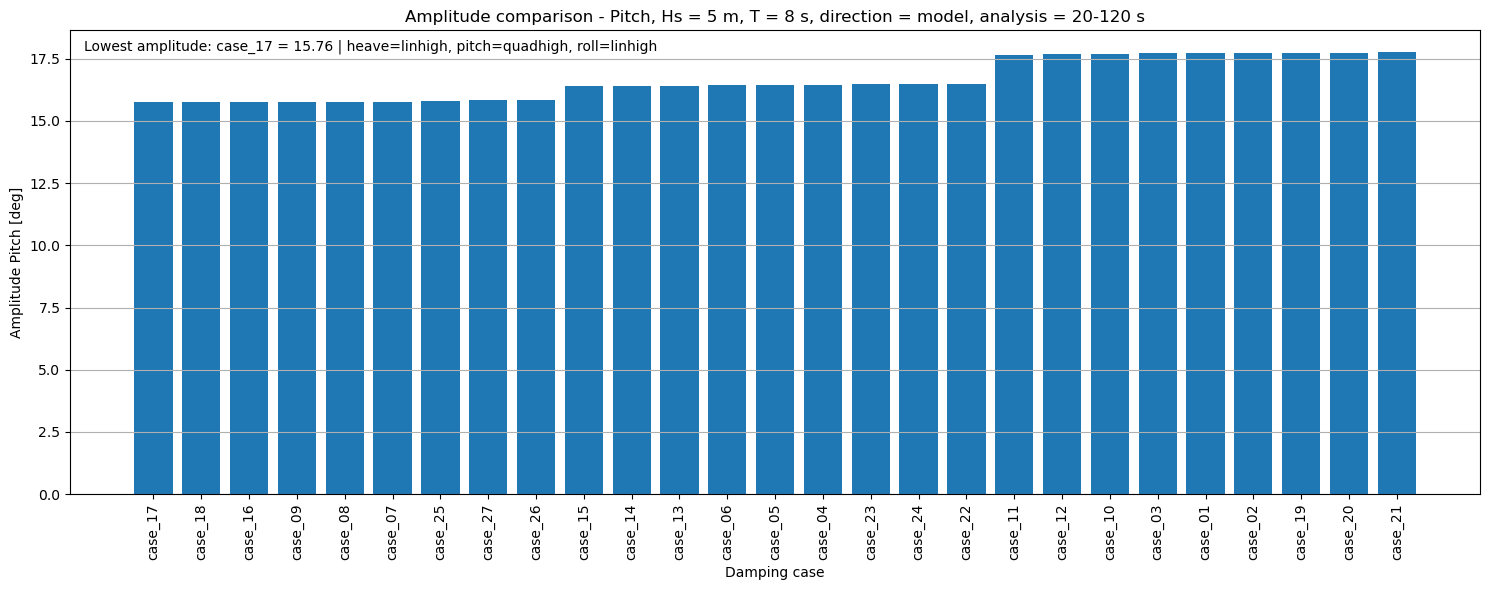

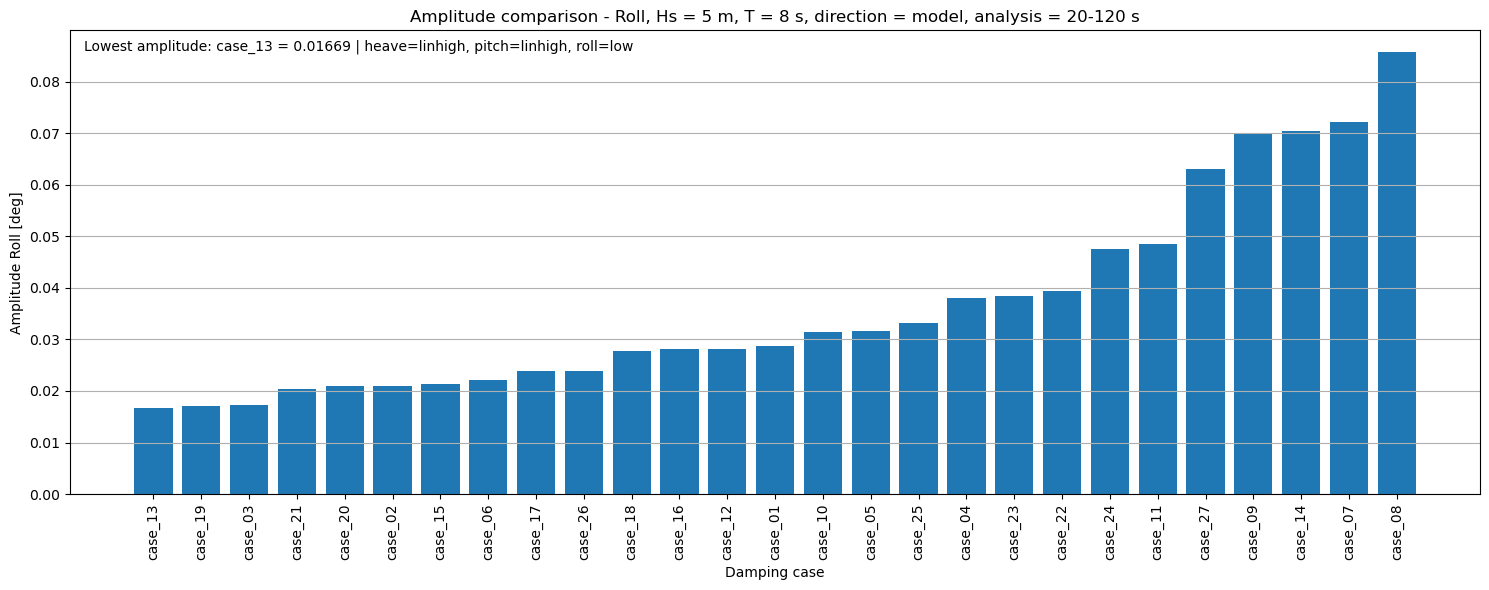

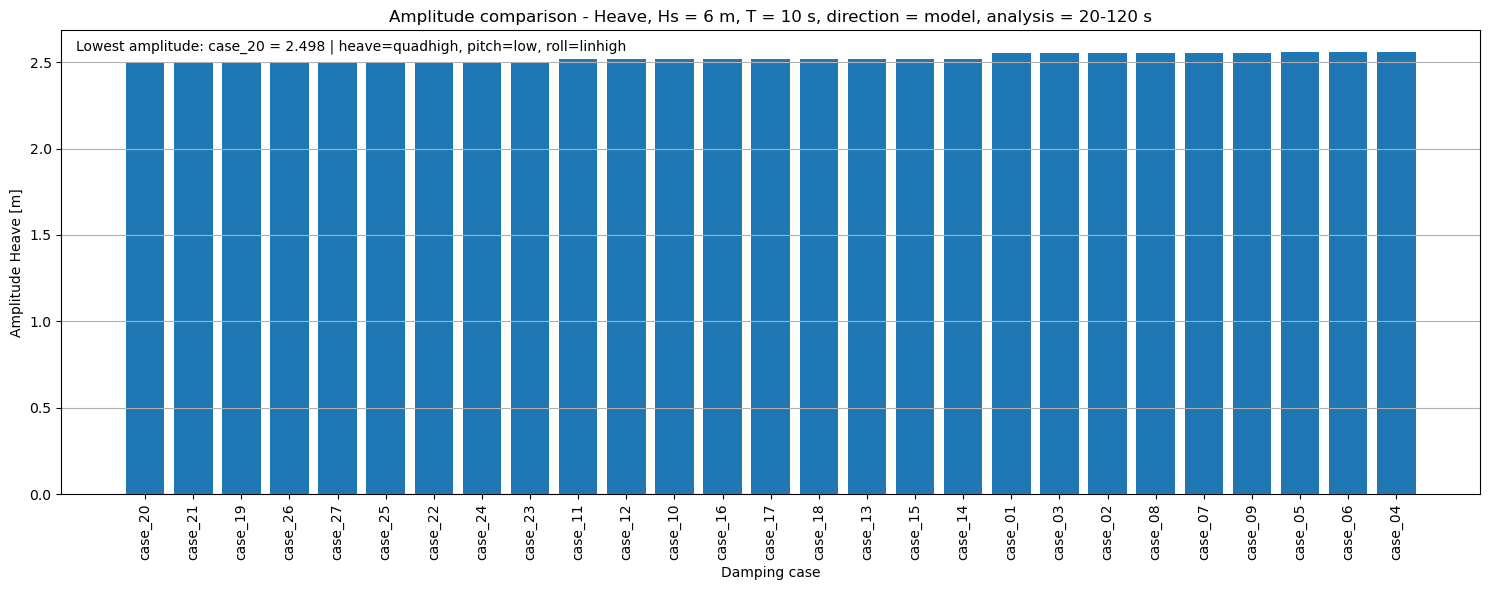

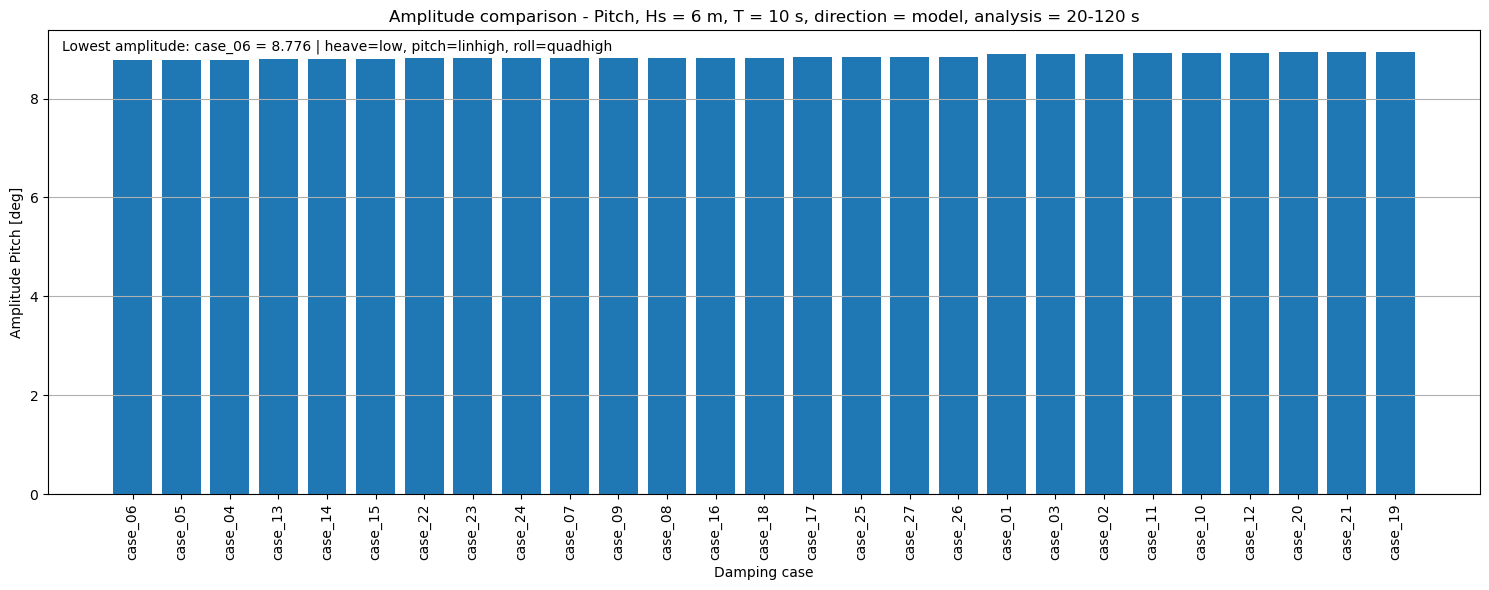

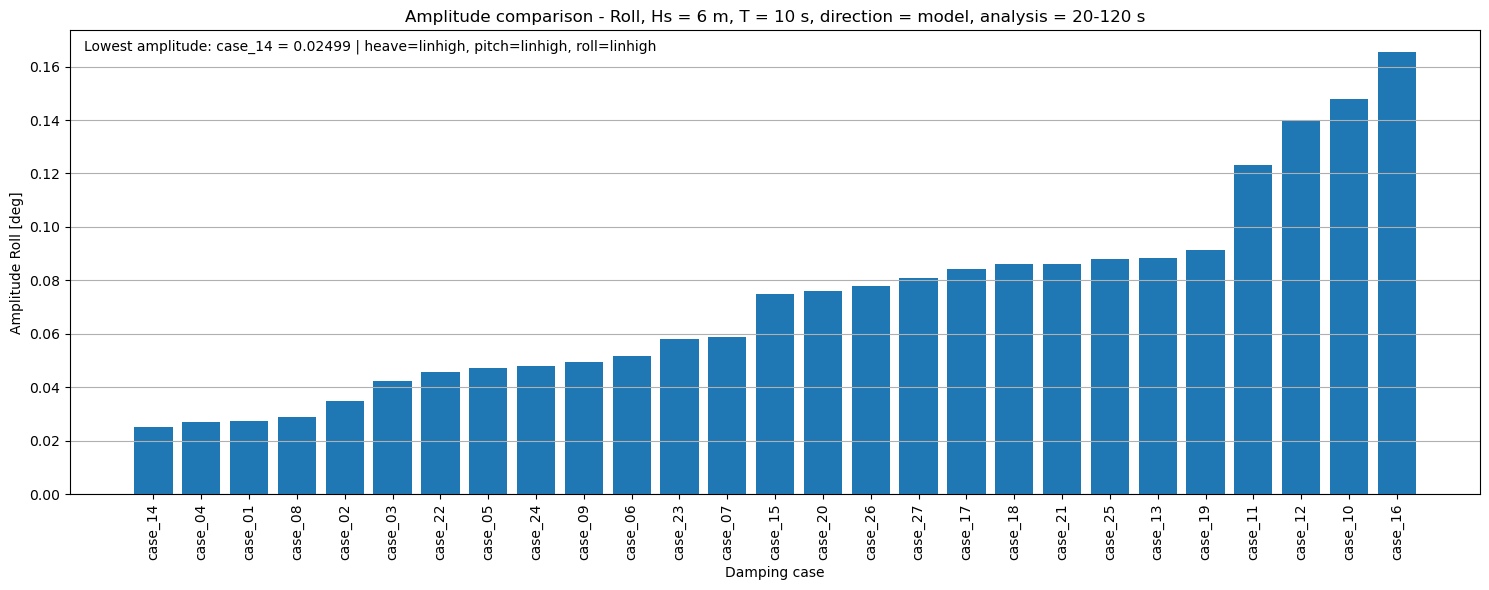

Opgeslagen amplitudefiguren:
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp2_Dirmodel_heave_amplitude_comparison.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp2_Dirmodel_pitch_amplitude_comparison.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp2_Dirmodel_roll_amplitude_comparison.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp4_Dirmodel_heave_amplitude_comparison.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp4_Dirmodel_pitch_amplitude_comparison.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp4_Dirmodel_roll_amplitude_comparison.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs2_Tp4_Dirmodel_heave_amplitude_comparison.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulatio

In [18]:
# ============================================================
# 8. Amplitudeplots: verschillen tussen cases
# ============================================================
# Per sea state en response wordt de amplitude gesorteerd van laag naar hoog.

saved_amplitude_figures = []

for sea_state in sea_conditions:
    Hs = float(sea_state["Hs"])
    Tp = float(sea_state["Tp"])
    direction = sea_state.get("direction", None)
    direction_label = "model" if direction is None else f"{float(direction):g}°"
    sea_key = sea_key_from_state(sea_state)

    for response_name, (response_title, ylabel) in response_labels.items():
        df = ok_metrics[
            ok_metrics["sea_key"].eq(sea_key) &
            ok_metrics["response"].eq(response_name)
        ].copy()

        if df.empty:
            continue

        df = df.sort_values("amplitude", ascending=True)
        x = np.arange(len(df))

        fig, ax = plt.subplots(figsize=(15, 6))
        ax.bar(x, df["amplitude"].values)
        ax.set_xticks(x)
        ax.set_xticklabels(df["case"].values, rotation=90)
        ax.set_xlabel("Damping case")
        ax.set_ylabel(f"Amplitude {ylabel}")
        ax.set_title(
            f"Amplitude comparison - {response_title}, Hs = {Hs:g} m, T = {Tp:g} s, "
            f"direction = {direction_label}, analysis = {analysis_start_time:g}-{analysis_end_time:g} s"
        )
        ax.grid(True, axis="y")

        best = df.iloc[0]
        subtitle = (
            f"Lowest amplitude: {best['case']} = {best['amplitude']:.4g} | "
            f"heave={best['heave_option']}, pitch={best['pitch_option']}, roll={best['roll_option']}"
        )
        ax.text(0.01, 0.98, subtitle, transform=ax.transAxes, va="top", ha="left")

        fig.tight_layout()

        if save_plots:
            filename = output_dir / f"{safe_name(sea_key)}_{response_name}_amplitude_comparison.png"
            fig.savefig(filename, dpi=300, bbox_inches="tight")
            saved_amplitude_figures.append(filename)

        if show_plots:
            plt.show()
        else:
            plt.close(fig)

print("Opgeslagen amplitudefiguren:")
for f in saved_amplitude_figures:
    print(f)

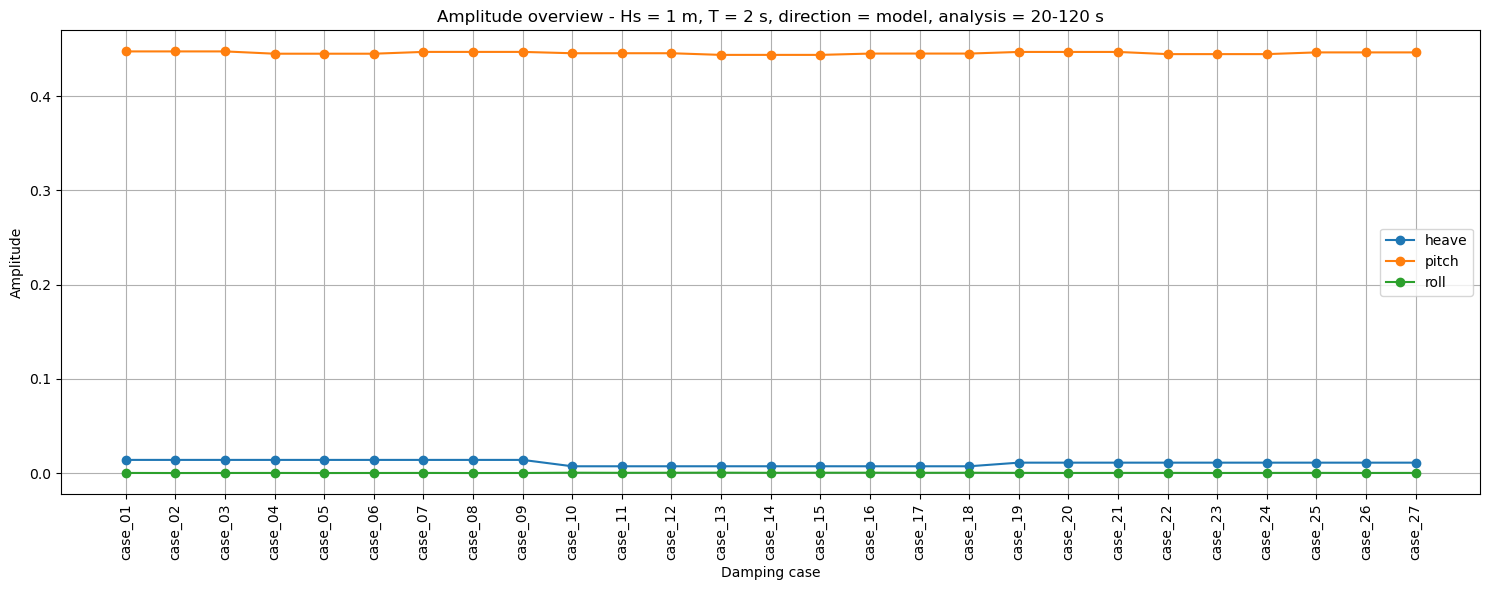

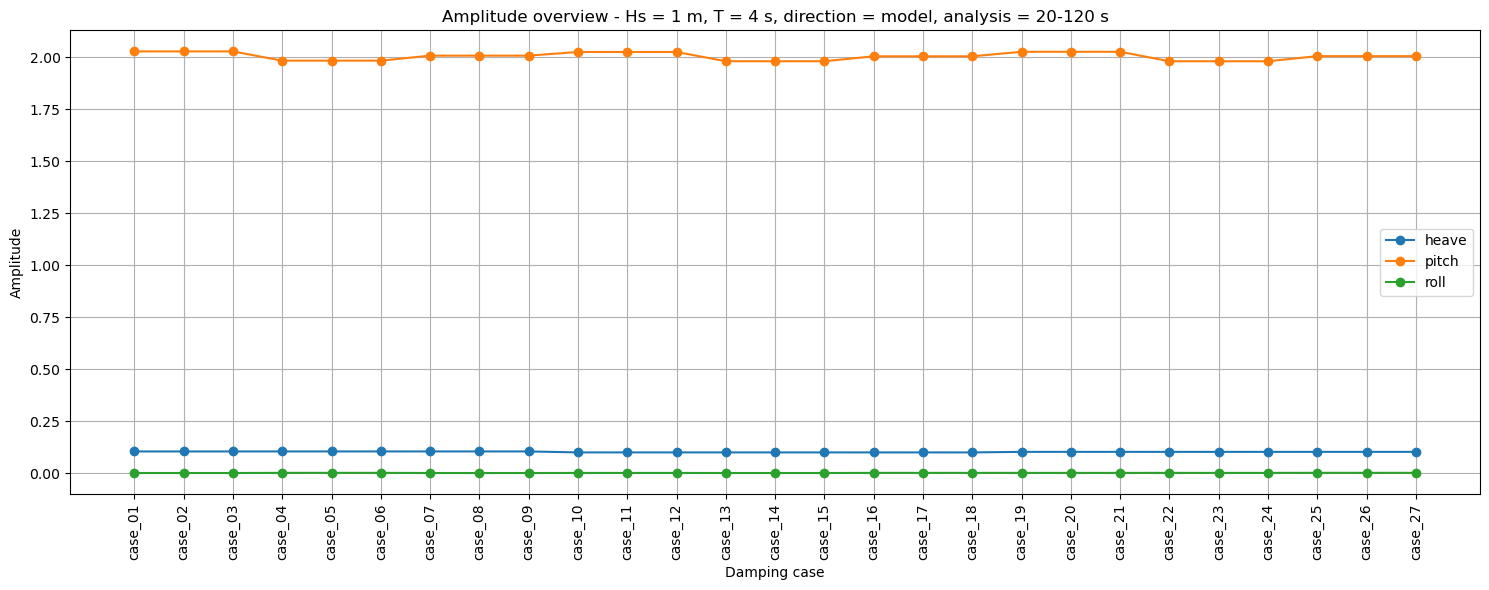

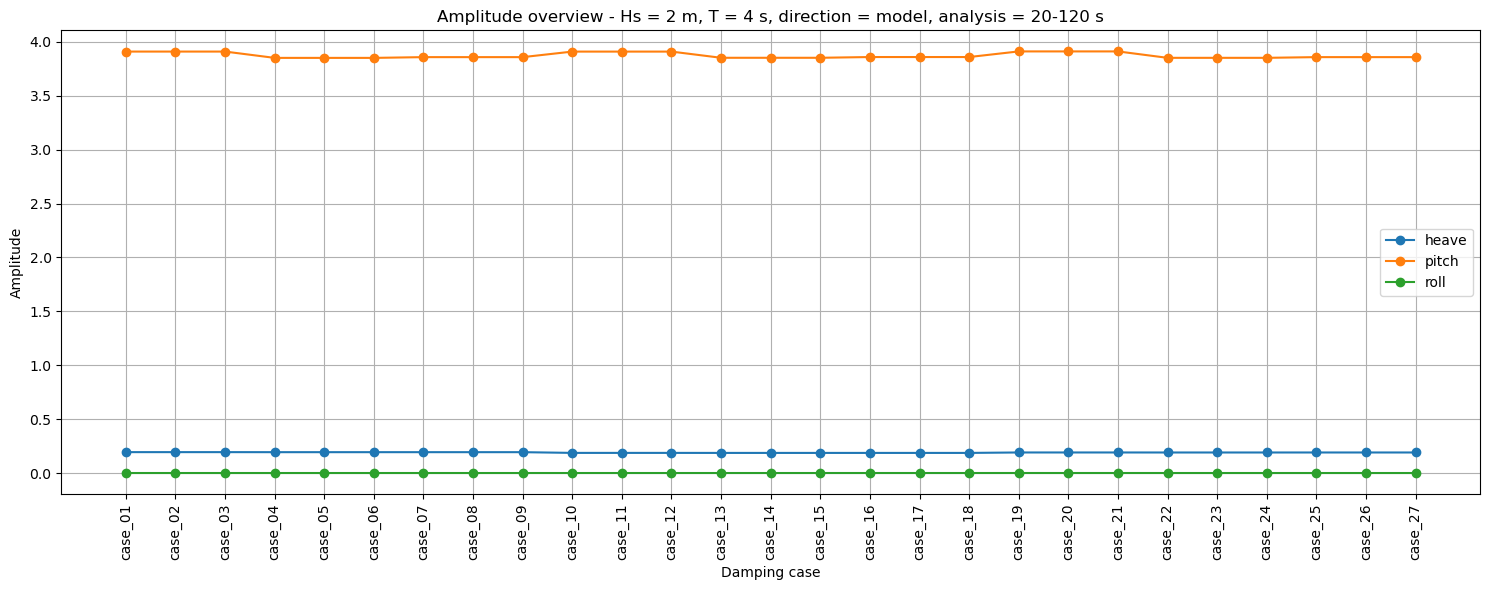

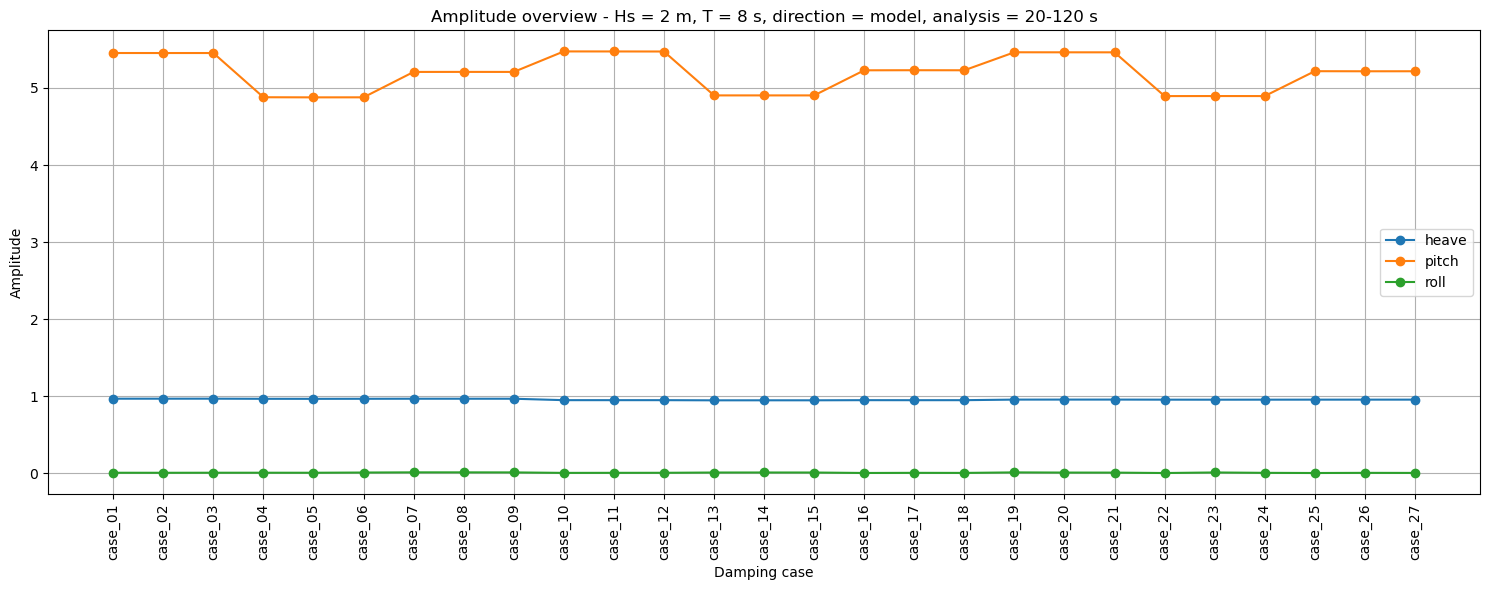

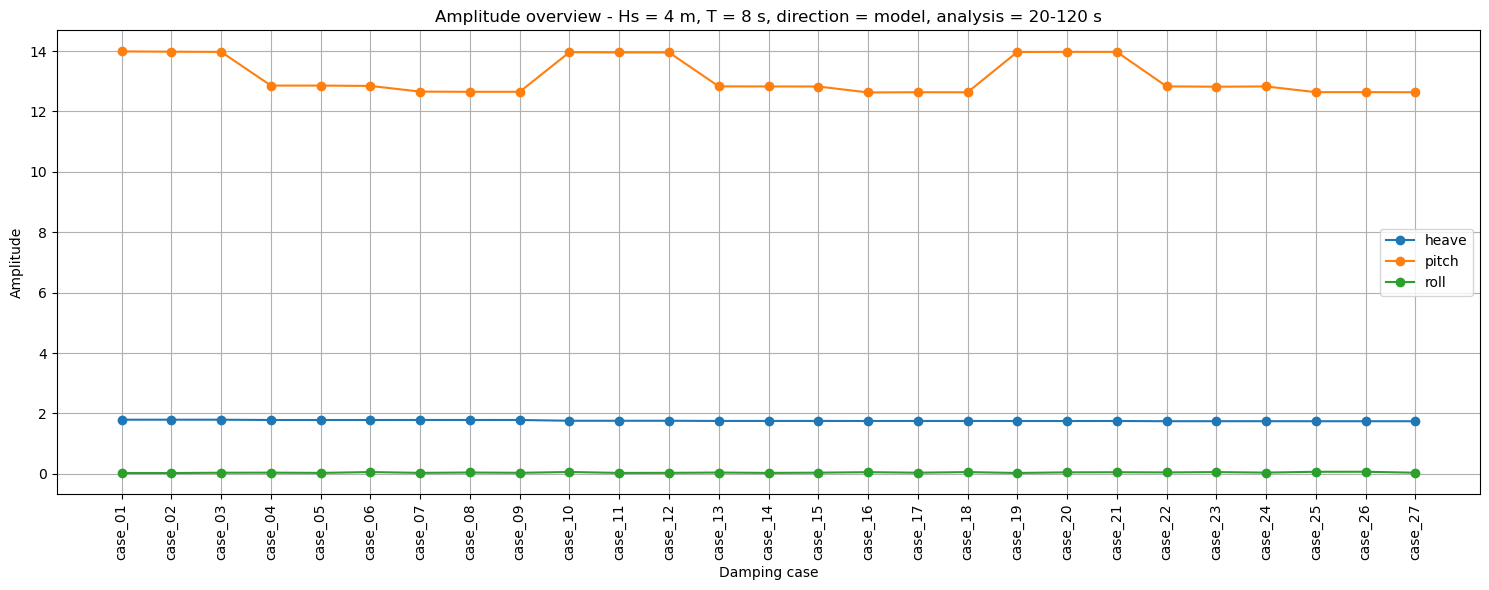

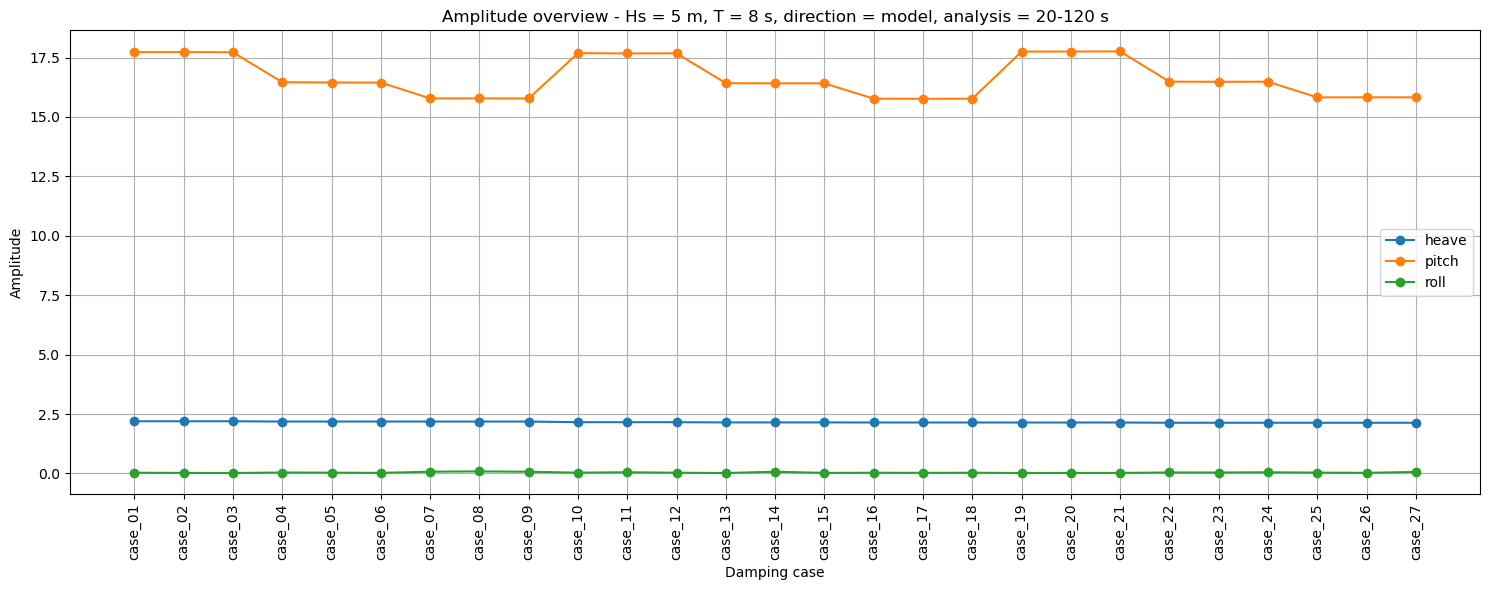

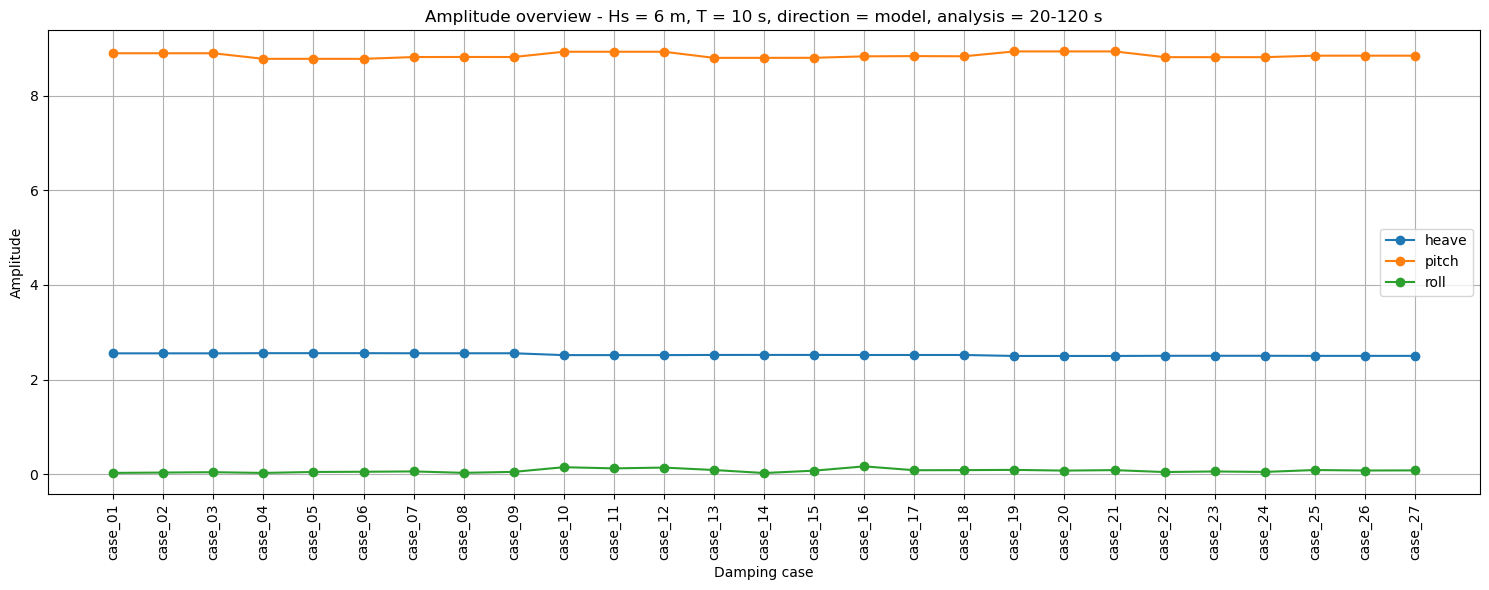

Opgeslagen overzichtsfiguren:
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp2_Dirmodel_amplitude_overview_all_responses.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs1_Tp4_Dirmodel_amplitude_overview_all_responses.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs2_Tp4_Dirmodel_amplitude_overview_all_responses.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs2_Tp8_Dirmodel_amplitude_overview_all_responses.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs4_Tp8_Dirmodel_amplitude_overview_all_responses.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs5_Tp8_Dirmodel_amplitude_overview_all_responses.png
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\Hs6_Tp10_Dirmodel_amplitude_overview_all_responses.png


In [19]:
# ============================================================
# 9. Extra overzichtsplot: amplitude per case voor alle responses
# ============================================================
# Dit geeft per sea state een compacte vergelijking van heave, pitch en roll.

saved_summary_figures = []

for sea_state in sea_conditions:
    Hs = float(sea_state["Hs"])
    Tp = float(sea_state["Tp"])
    direction = sea_state.get("direction", None)
    direction_label = "model" if direction is None else f"{float(direction):g}°"
    sea_key = sea_key_from_state(sea_state)

    df = ok_metrics[ok_metrics["sea_key"].eq(sea_key)].copy()
    if df.empty:
        continue

    fig, ax = plt.subplots(figsize=(15, 6))

    for response_name in ["heave", "pitch", "roll"]:
        dfr = df[df["response"].eq(response_name)].copy()
        dfr = dfr.set_index("case").reindex(DAMPING_CASES.keys()).reset_index()
        ax.plot(dfr["case"], dfr["amplitude"], marker="o", linewidth=1.5, label=response_name)

    ax.set_xlabel("Damping case")
    ax.set_ylabel("Amplitude")
    ax.set_title(
        f"Amplitude overview - Hs = {Hs:g} m, T = {Tp:g} s, "
        f"direction = {direction_label}, analysis = {analysis_start_time:g}-{analysis_end_time:g} s"
    )
    ax.grid(True)
    ax.legend()
    ax.tick_params(axis="x", rotation=90)
    fig.tight_layout()

    if save_plots:
        filename = output_dir / f"{safe_name(sea_key)}_amplitude_overview_all_responses.png"
        fig.savefig(filename, dpi=300, bbox_inches="tight")
        saved_summary_figures.append(filename)

    if show_plots:
        plt.show()
    else:
        plt.close(fig)

print("Opgeslagen overzichtsfiguren:")
for f in saved_summary_figures:
    print(f)

In [20]:
# ============================================================
# 10. Resultaten opslaan in Excel
# ============================================================

excel_path = output_dir / "orca_27_damping_cases_results.xlsx"

with pd.ExcelWriter(excel_path) as writer:
    cases_df.to_excel(writer, sheet_name="damping_cases", index=False)
    metrics_df.to_excel(writer, sheet_name="response_metrics", index=False)
    best_cases.to_excel(writer, sheet_name="best_cases", index=False)

print(f"Excelbestand opgeslagen naar: {excel_path}")

Excelbestand opgeslagen naar: C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulations_regular\orca_27_damping_cases_results.xlsx
